# 📊 EDA — Phân tích Khám phá Dữ liệu Chess Lichess
## Mục tiêu: Đánh giá tính khả thi của mô hình dự đoán ELO từ vài nước đi đầu tiên (realtime)

**Dataset**: ~187.3 triệu ván cờ từ Lichess (Dec 2025 + Jan 2026)  
**Phương pháp**: Polars LazyFrame + Stratified Sampling + XGBoost GPU Feature Importance

---

### Mục lục
1. **Phase 1** — Data Loading & Quality Check
2. **Phase 2** — Univariate Analysis (Phân phối ELO, ECO, GameFormat, Termination)
3. **Phase 3** — Bivariate Analysis (ECO×ELO, EloDiff×Result, Format×ELO)
4. **Phase 4** — Move Sequence Analysis (First-N-moves, Opening diversity, N-gram)
5. **Phase 5** — Multivariate & Feature Importance (Correlation, XGBoost GPU, Feasibility)
6. **Tổng kết** — Executive Summary & Next Steps

In [1]:
# ── Imports ──────────────────────────────────────────────────
import sys, os, gc, warnings, time
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from collections import Counter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*DMatrix.*")

# ── Import config từ project root ────────────────────────────
sys.path.insert(0, str(Path.cwd().parent))
from src.config import DATA_PROCESSED, EDA_OUTPUTS

# ── Visualization defaults ───────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
})

# ── Constants ────────────────────────────────────────────────
SAMPLE_SIZE   = 3_000_000
RANDOM_SEED   = 42

# Fine-grained bins (10) cho EDA — thấy rõ phân phối
ELO_BINS   = [0, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2500, 3500]
ELO_LABELS = ['<800', '800-1000', '1000-1200', '1200-1400', '1400-1600',
              '1600-1800', '1800-2000', '2000-2200', '2200-2500', '2500+']

# Coarse-grained bands (5) cho model — đủ samples mỗi class
MODEL_BINS   = [0, 1000, 1400, 1800, 2200, 3500]
MODEL_LABELS = ['Beginner', 'Intermediate', 'Advanced', 'Expert', 'Master']

# Phase 4 — move sequence analysis constants
MOVE_SAMPLE_SIZE = 500_000    # số ván có Moves để phân tích sequence
OVERSAMPLE_TOTAL = MOVE_SAMPLE_SIZE * 10  # 5M raw trước khi lọc

def save_plot(fig, name: str):
    """Lưu biểu đồ ra eda/outputs/ với format chuẩn."""
    path = EDA_OUTPUTS / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  ✅ Đã lưu: {path}")

print("✅ Imports OK")
print(f"  Polars {pl.__version__}")
print(f"  Data dir: {DATA_PROCESSED}")
print(f"  Output dir: {EDA_OUTPUTS}")

✅ Imports OK
  Polars 1.38.1
  Data dir: /home/sakana/Code/PTIT/MMDs/MMD-G2/data/processed
  Output dir: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs


---
# Phase 1 — Data Loading & Quality Check
> Mục tiêu: Load dữ liệu bằng Polars LazyFrame, kiểm tra schema, null values, và tạo stratified sample

In [2]:
# ── 1.1 Data Loading — Polars LazyFrame (zero-copy, lazy eval) ──
t0 = time.time()

# Liệt kê parquet files
for f in sorted(DATA_PROCESSED.glob("*.parquet")):
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  📁 {f.name}: {size_gb:.2f} GB")

# Lazy scan — KHÔNG load vào RAM
lf = pl.scan_parquet(DATA_PROCESSED / "*.parquet")

# Schema
print("\n📋 Schema:")
for col_name, dtype in lf.collect_schema().items():
    print(f"  {col_name:<20} {dtype}")

# Đếm tổng số rows (lazy aggregation)
total_rows = lf.select(pl.len()).collect().item()
print(f"\n📊 Tổng số ván: {total_rows:,.0f}")
print(f"  ⏱ Scan time: {time.time() - t0:.1f}s")

  📁 lichess_2025-12_ml.parquet: 22.51 GB
  📁 lichess_2026-01_ml.parquet: 22.42 GB

📋 Schema:
  Result               Categorical
  WhiteElo             Int16
  BlackElo             Int16
  EloAvg               Int16
  NumMoves             Int16
  WhiteRatingDiff      Int16
  BlackRatingDiff      Int16
  ECO                  Categorical
  Termination          Categorical
  Moves                String
  ResultNumeric        Float32
  BaseTime             Int16
  Increment            Int16
  GameFormat           Categorical

📊 Tổng số ván: 187,320,359
  ⏱ Scan time: 0.0s


In [3]:
# ── 1.2 Full Dataset Statistics (lazy — chạy trên disk) ─────
t0 = time.time()

# Thống kê mô tả numeric columns trên TOÀN BỘ dataset
numeric_cols = ['WhiteElo', 'BlackElo', 'EloAvg', 'NumMoves',
                'WhiteRatingDiff', 'BlackRatingDiff', 'BaseTime', 'Increment']

full_stats = (
    lf
    .select([
        pl.col(c).mean().alias(f"{c}_mean") for c in numeric_cols
    ] + [
        pl.col(c).std().alias(f"{c}_std") for c in numeric_cols
    ] + [
        pl.col(c).min().alias(f"{c}_min") for c in numeric_cols
    ] + [
        pl.col(c).max().alias(f"{c}_max") for c in numeric_cols
    ] + [
        pl.col(c).median().alias(f"{c}_median") for c in numeric_cols
    ] + [
        pl.col(c).null_count().alias(f"{c}_nulls") for c in numeric_cols
    ] + [
        pl.len().alias("total_rows")
    ])
    .collect()
)

# Format thành bảng đẹp
print("📊 Full Dataset Statistics (187M+ rows):")
print(f"{'Column':<22} {'Mean':>10} {'Std':>10} {'Min':>8} {'Median':>10} {'Max':>8} {'Nulls':>10}")
print("─" * 80)
for c in numeric_cols:
    mean_v = full_stats[f"{c}_mean"][0]
    std_v  = full_stats[f"{c}_std"][0]
    min_v  = full_stats[f"{c}_min"][0]
    med_v  = full_stats[f"{c}_median"][0]
    max_v  = full_stats[f"{c}_max"][0]
    null_v = full_stats[f"{c}_nulls"][0]
    print(f"  {c:<20} {mean_v:>10.1f} {std_v:>10.1f} {min_v:>8} {med_v:>10.1f} {max_v:>8} {null_v:>10,}")

print(f"\n  ⏱ Full scan time: {time.time() - t0:.1f}s")

📊 Full Dataset Statistics (187M+ rows):
Column                       Mean        Std      Min     Median      Max      Nulls
────────────────────────────────────────────────────────────────────────────────
  WhiteElo                 1650.7      404.8      400     1663.0     3999          0
  BlackElo                 1650.5      404.9      400     1663.0     3999          0
  EloAvg                   1650.4      400.5      400     1664.0     3748          0
  NumMoves                   66.9       30.5        5       63.0      600          0
  WhiteRatingDiff            -0.6       21.8     -700        1.0      700    608,039
  BlackRatingDiff            -0.5       19.4     -700       -1.0      700    608,040
  BaseTime                  240.6      257.8        0      180.0    10800     94,239
  Increment                   0.7        2.3        0        0.0      180     94,239

  ⏱ Full scan time: 1.9s


In [4]:
# ── 1.3 Categorical Value Counts (lazy) ─────────────────────
t0 = time.time()

cat_cols = ['Result', 'ECO', 'Termination', 'GameFormat']
for col in cat_cols:
    vc = (
        lf
        .group_by(col)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(10)
        .collect()
    )
    total = vc["count"].sum()
    print(f"\n📊 {col} — Top values:")
    for row in vc.iter_rows():
        pct = row[1] / total_rows * 100
        print(f"  {str(row[0]):<30} {row[1]:>12,}  ({pct:.1f}%)")

print(f"\n  ⏱ Categorical scan time: {time.time() - t0:.1f}s")


📊 Result — Top values:
  1-0                              93,191,778  (49.7%)
  0-1                              86,842,806  (46.4%)
  1/2-1/2                           7,285,775  (3.9%)

📊 ECO — Top values:
  A00                              11,671,119  (6.2%)
  A40                              10,745,390  (5.7%)
  B01                              10,242,815  (5.5%)
  B00                               8,760,842  (4.7%)
  D00                               8,057,803  (4.3%)
  C00                               6,811,443  (3.6%)
  C50                               5,124,870  (2.7%)
  B10                               4,767,727  (2.5%)
  C20                               4,488,918  (2.4%)
  D02                               4,317,902  (2.3%)

📊 Termination — Top values:
  Normal                          126,613,778  (67.6%)
  Time forfeit                     60,678,011  (32.4%)
  Insufficient material                23,061  (0.0%)
  Rules infraction                      5,509  (0.0%)

📊 G

In [5]:
# ── 1.4 Stratified Sampling — 3M rows đại diện ─────────────
t0 = time.time()

# Bước 1: Scan metadata (KHÔNG load cột Moves — tiết kiệm RAM)
# Thêm EloBand để stratify
lf_meta = (
    lf
    .select(pl.exclude("Moves"))
    .with_columns(
        pl.col("EloAvg")
          .cut(ELO_BINS[1:-1], labels=ELO_LABELS)
          .alias("EloBand")
    )
)

# Bước 2: Collect với streaming mode (tránh OOM)
print("⏳ Collecting metadata (streaming)...")
df_meta = lf_meta.collect(engine="streaming")
print(f"  Loaded {len(df_meta):,} rows (không có cột Moves)")
print(f"  RAM usage: ~{df_meta.estimated_size('gb'):.2f} GB")

# Bước 3: Stratified sample theo EloBand
# Mỗi band lấy tỉ lệ đều, tổng ~3M rows
n_per_band = SAMPLE_SIZE // len(ELO_LABELS)
samples = []
print(f"\n🎯 Stratified sampling ({SAMPLE_SIZE:,} target, ~{n_per_band:,}/band):")
for band in ELO_LABELS:
    band_df = df_meta.filter(pl.col("EloBand") == band)
    n_take = min(len(band_df), n_per_band)
    band_sample = band_df.sample(n=n_take, seed=RANDOM_SEED)
    samples.append(band_sample)
    print(f"  {band:<15} population: {len(band_df):>12,}  sampled: {n_take:>8,}")

df_sample = pl.concat(samples).sample(fraction=1.0, seed=RANDOM_SEED)  # Shuffle
print(f"\n✅ Sample: {len(df_sample):,} rows, ~{df_sample.estimated_size('gb'):.2f} GB")
print(f"  ⏱ Sampling time: {time.time() - t0:.1f}s")

# Cleanup
del df_meta, samples
gc.collect()

⏳ Collecting metadata (streaming)...
  Loaded 187,320,359 rows (không có cột Moves)
  RAM usage: ~7.07 GB

🎯 Stratified sampling (3,000,000 target, ~300,000/band):
  <800            population:    2,745,427  sampled:  300,000
  800-1000        population:    8,139,061  sampled:  300,000
  1000-1200       population:   15,798,376  sampled:  300,000
  1200-1400       population:   23,777,396  sampled:  300,000
  1400-1600       population:   31,998,077  sampled:  300,000
  1600-1800       population:   36,072,613  sampled:  300,000
  1800-2000       population:   32,876,681  sampled:  300,000
  2000-2200       population:   21,055,592  sampled:  300,000
  2200-2500       population:   12,112,073  sampled:  300,000
  2500+           population:    2,745,063  sampled:  300,000

✅ Sample: 3,000,000 rows, ~0.11 GB
  ⏱ Sampling time: 8.0s


20

In [6]:
# ── 1.5 Derived Features cho sample ──────────────────────────
df_sample = df_sample.with_columns([
    # EloDiff: chênh lệch ELO (White - Black)
    (pl.col("WhiteElo") - pl.col("BlackElo")).cast(pl.Int16).alias("EloDiff"),
    # EcoCategory: nhóm khai cuộc chính (A/B/C/D/E)
    pl.col("ECO").cast(pl.Utf8).str.slice(0, 1).alias("EcoCategory"),
    # Coarse-grained bands cho model
    pl.col("EloAvg")
      .cut(MODEL_BINS[1:-1], labels=MODEL_LABELS)
      .alias("ModelBand"),
])

# Data quality check
print("📋 Data Quality Check (sample):")
null_counts = df_sample.null_count()
has_nulls = False
for col_name in null_counts.columns:
    n = null_counts[col_name][0]
    if n > 0:
        print(f"  ⚠️  {col_name}: {n:,} nulls ({n/len(df_sample)*100:.2f}%)")
        has_nulls = True
if not has_nulls:
    print("  ✅ Không có null values!")

# ECO validation
eco_invalid_count = df_sample.filter(
    ~pl.col("ECO").cast(pl.Utf8).str.contains(r"^[A-E]\d{2}$")
).height
print(f"  ECO không hợp lệ: {eco_invalid_count:,} rows")

# Mô tả sample
print(f"\n📊 Sample shape: {df_sample.shape}")
print(f"  Columns: {df_sample.columns}")

📋 Data Quality Check (sample):
  ⚠️  WhiteRatingDiff: 9,963 nulls (0.33%)
  ⚠️  BlackRatingDiff: 9,963 nulls (0.33%)
  ⚠️  BaseTime: 1,121 nulls (0.04%)
  ⚠️  Increment: 1,121 nulls (0.04%)
  ECO không hợp lệ: 0 rows

📊 Sample shape: (3000000, 17)
  Columns: ['Result', 'WhiteElo', 'BlackElo', 'EloAvg', 'NumMoves', 'WhiteRatingDiff', 'BlackRatingDiff', 'ECO', 'Termination', 'ResultNumeric', 'BaseTime', 'Increment', 'GameFormat', 'EloBand', 'EloDiff', 'EcoCategory', 'ModelBand']


---
# Phase 2 — Univariate Analysis
> Phân tích phân phối của từng biến riêng lẻ.  
> **Câu hỏi chính**: Phân phối ELO có dạng gì? Có bias nào cần xử lý? Feature nào có tín hiệu mạnh?

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/01_elo_distribution.png


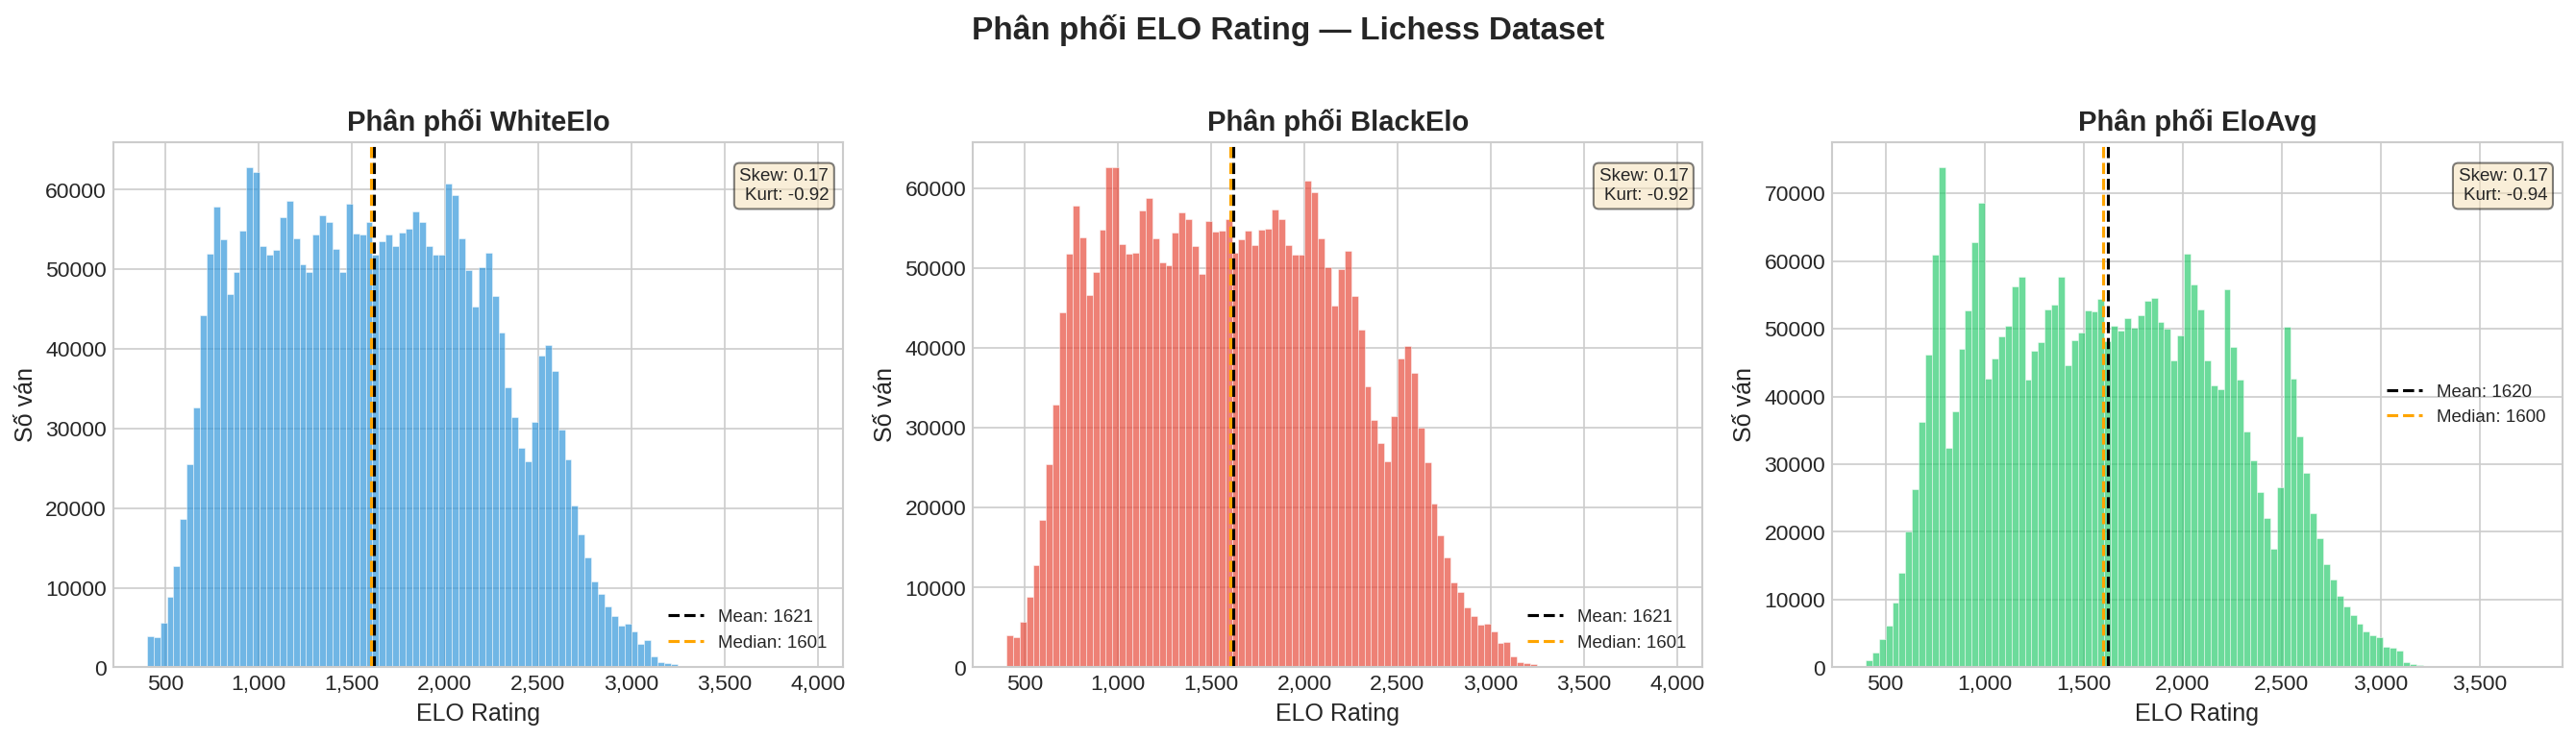

In [7]:
# ── 2.1 Phân phối ELO (WhiteElo, BlackElo, EloAvg) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

elo_cols = ['WhiteElo', 'BlackElo', 'EloAvg']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, col, color in zip(axes, elo_cols, colors):
    data = df_sample[col].to_numpy()
    ax.hist(data, bins=100, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(data):.0f}')
    ax.axvline(np.median(data), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {np.median(data):.0f}')
    ax.set_title(f'Phân phối {col}', fontweight='bold')
    ax.set_xlabel('ELO Rating')
    ax.set_ylabel('Số ván')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Skewness & Kurtosis
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    ax.text(0.98, 0.95, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Phân phối ELO Rating — Lichess Dataset', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
save_plot(fig, "01_elo_distribution")
plt.show()

/tmp/ipykernel_90833/1362344828.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_format, labels=unique_formats, patch_artist=True,


  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/02_elo_bands_and_format.png


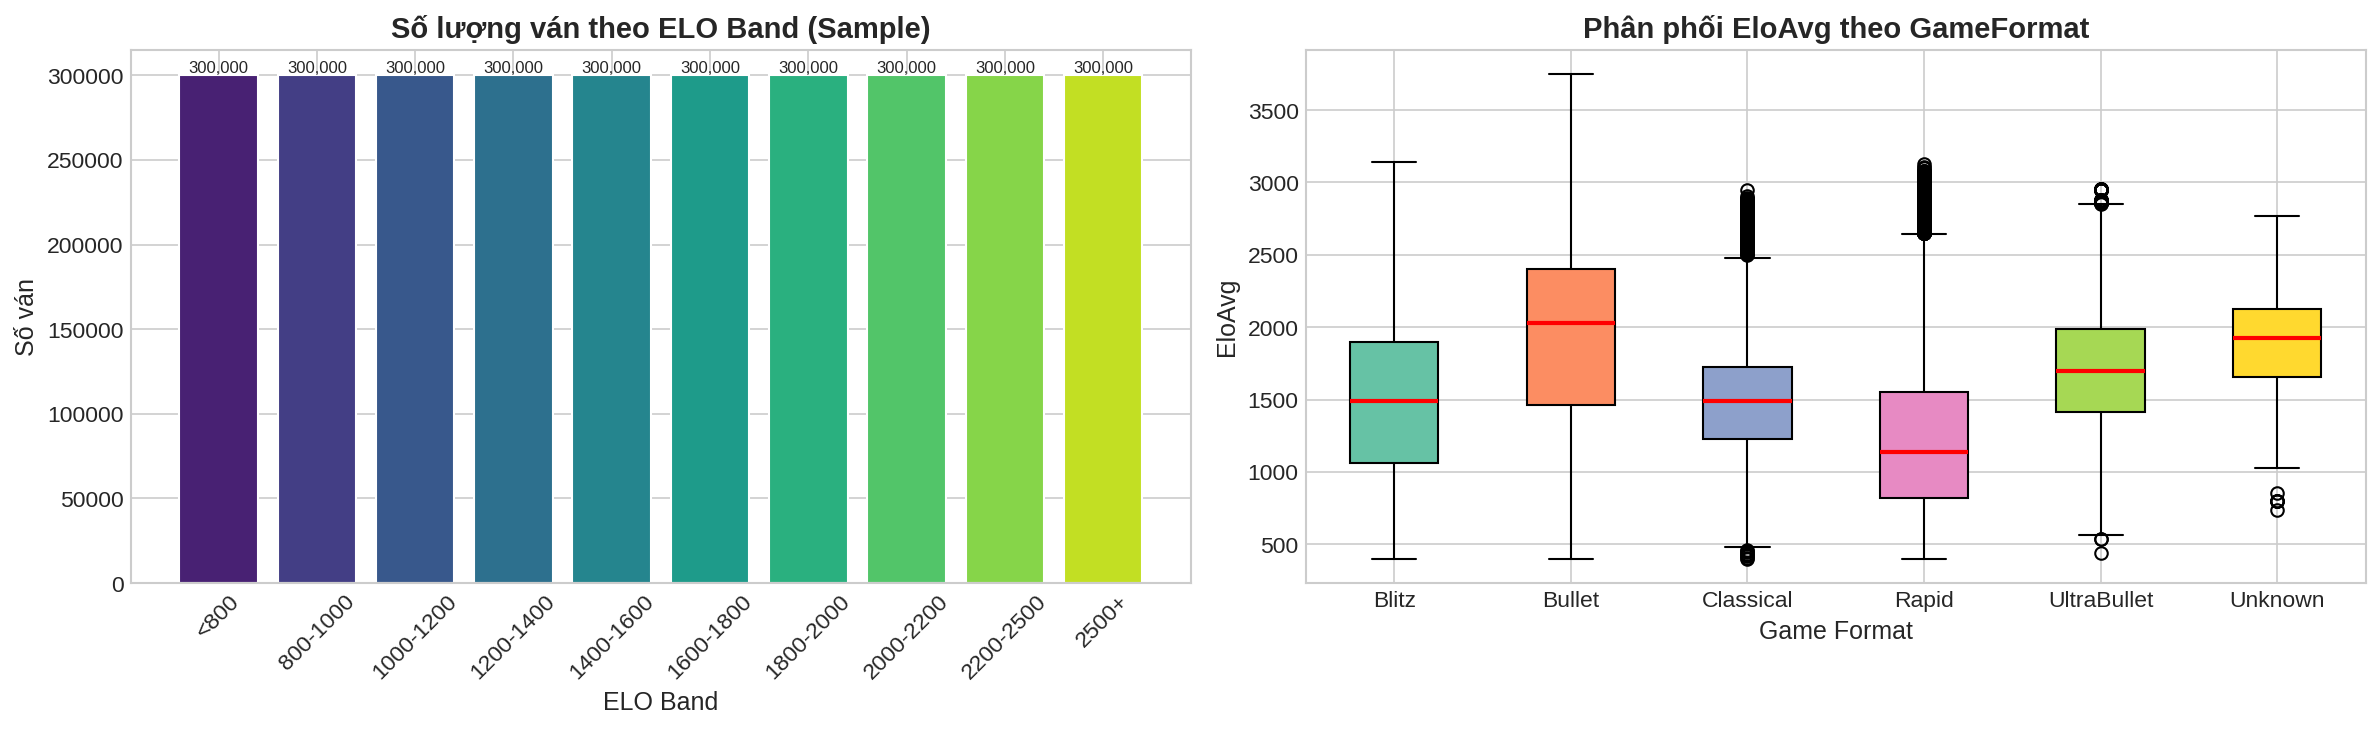

In [8]:
# ── 2.2 Phân phối ELO theo ELO Band (fine-grained) ──────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: số lượng ván theo ELO band
band_counts = df_sample.group_by("EloBand").agg(pl.len().alias("count")).sort("EloBand")
# Sắp xếp theo thứ tự ELO
band_order = {label: i for i, label in enumerate(ELO_LABELS)}
band_counts = band_counts.with_columns(
    pl.col("EloBand").cast(pl.Utf8).replace(band_order).cast(pl.Int32).alias("order")
).sort("order")

colors_band = sns.color_palette("viridis", len(ELO_LABELS))
bars = axes[0].bar(band_counts["EloBand"].cast(pl.Utf8).to_list(),
                   band_counts["count"].to_list(),
                   color=colors_band, edgecolor='white')
axes[0].set_title('Số lượng ván theo ELO Band (Sample)', fontweight='bold')
axes[0].set_xlabel('ELO Band')
axes[0].set_ylabel('Số ván')
axes[0].tick_params(axis='x', rotation=45)
# Annotate
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f'{h:,.0f}',
                ha='center', va='bottom', fontsize=8)

# Box plot: EloAvg theo GameFormat
game_formats = df_sample['GameFormat'].cast(pl.Utf8).to_list()
elo_avgs = df_sample['EloAvg'].to_list()
unique_formats = sorted(set(game_formats))
data_by_format = [[e for e, f in zip(elo_avgs, game_formats) if f == fmt] for fmt in unique_formats]
bp = axes[1].boxplot(data_by_format, tick_labels=unique_formats, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
palette = sns.color_palette("Set2", len(unique_formats))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
axes[1].set_title('Phân phối EloAvg theo GameFormat', fontweight='bold')
axes[1].set_xlabel('Game Format')
axes[1].set_ylabel('EloAvg')

fig.tight_layout()
save_plot(fig, "02_elo_bands_and_format")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/03_categorical_distributions.png


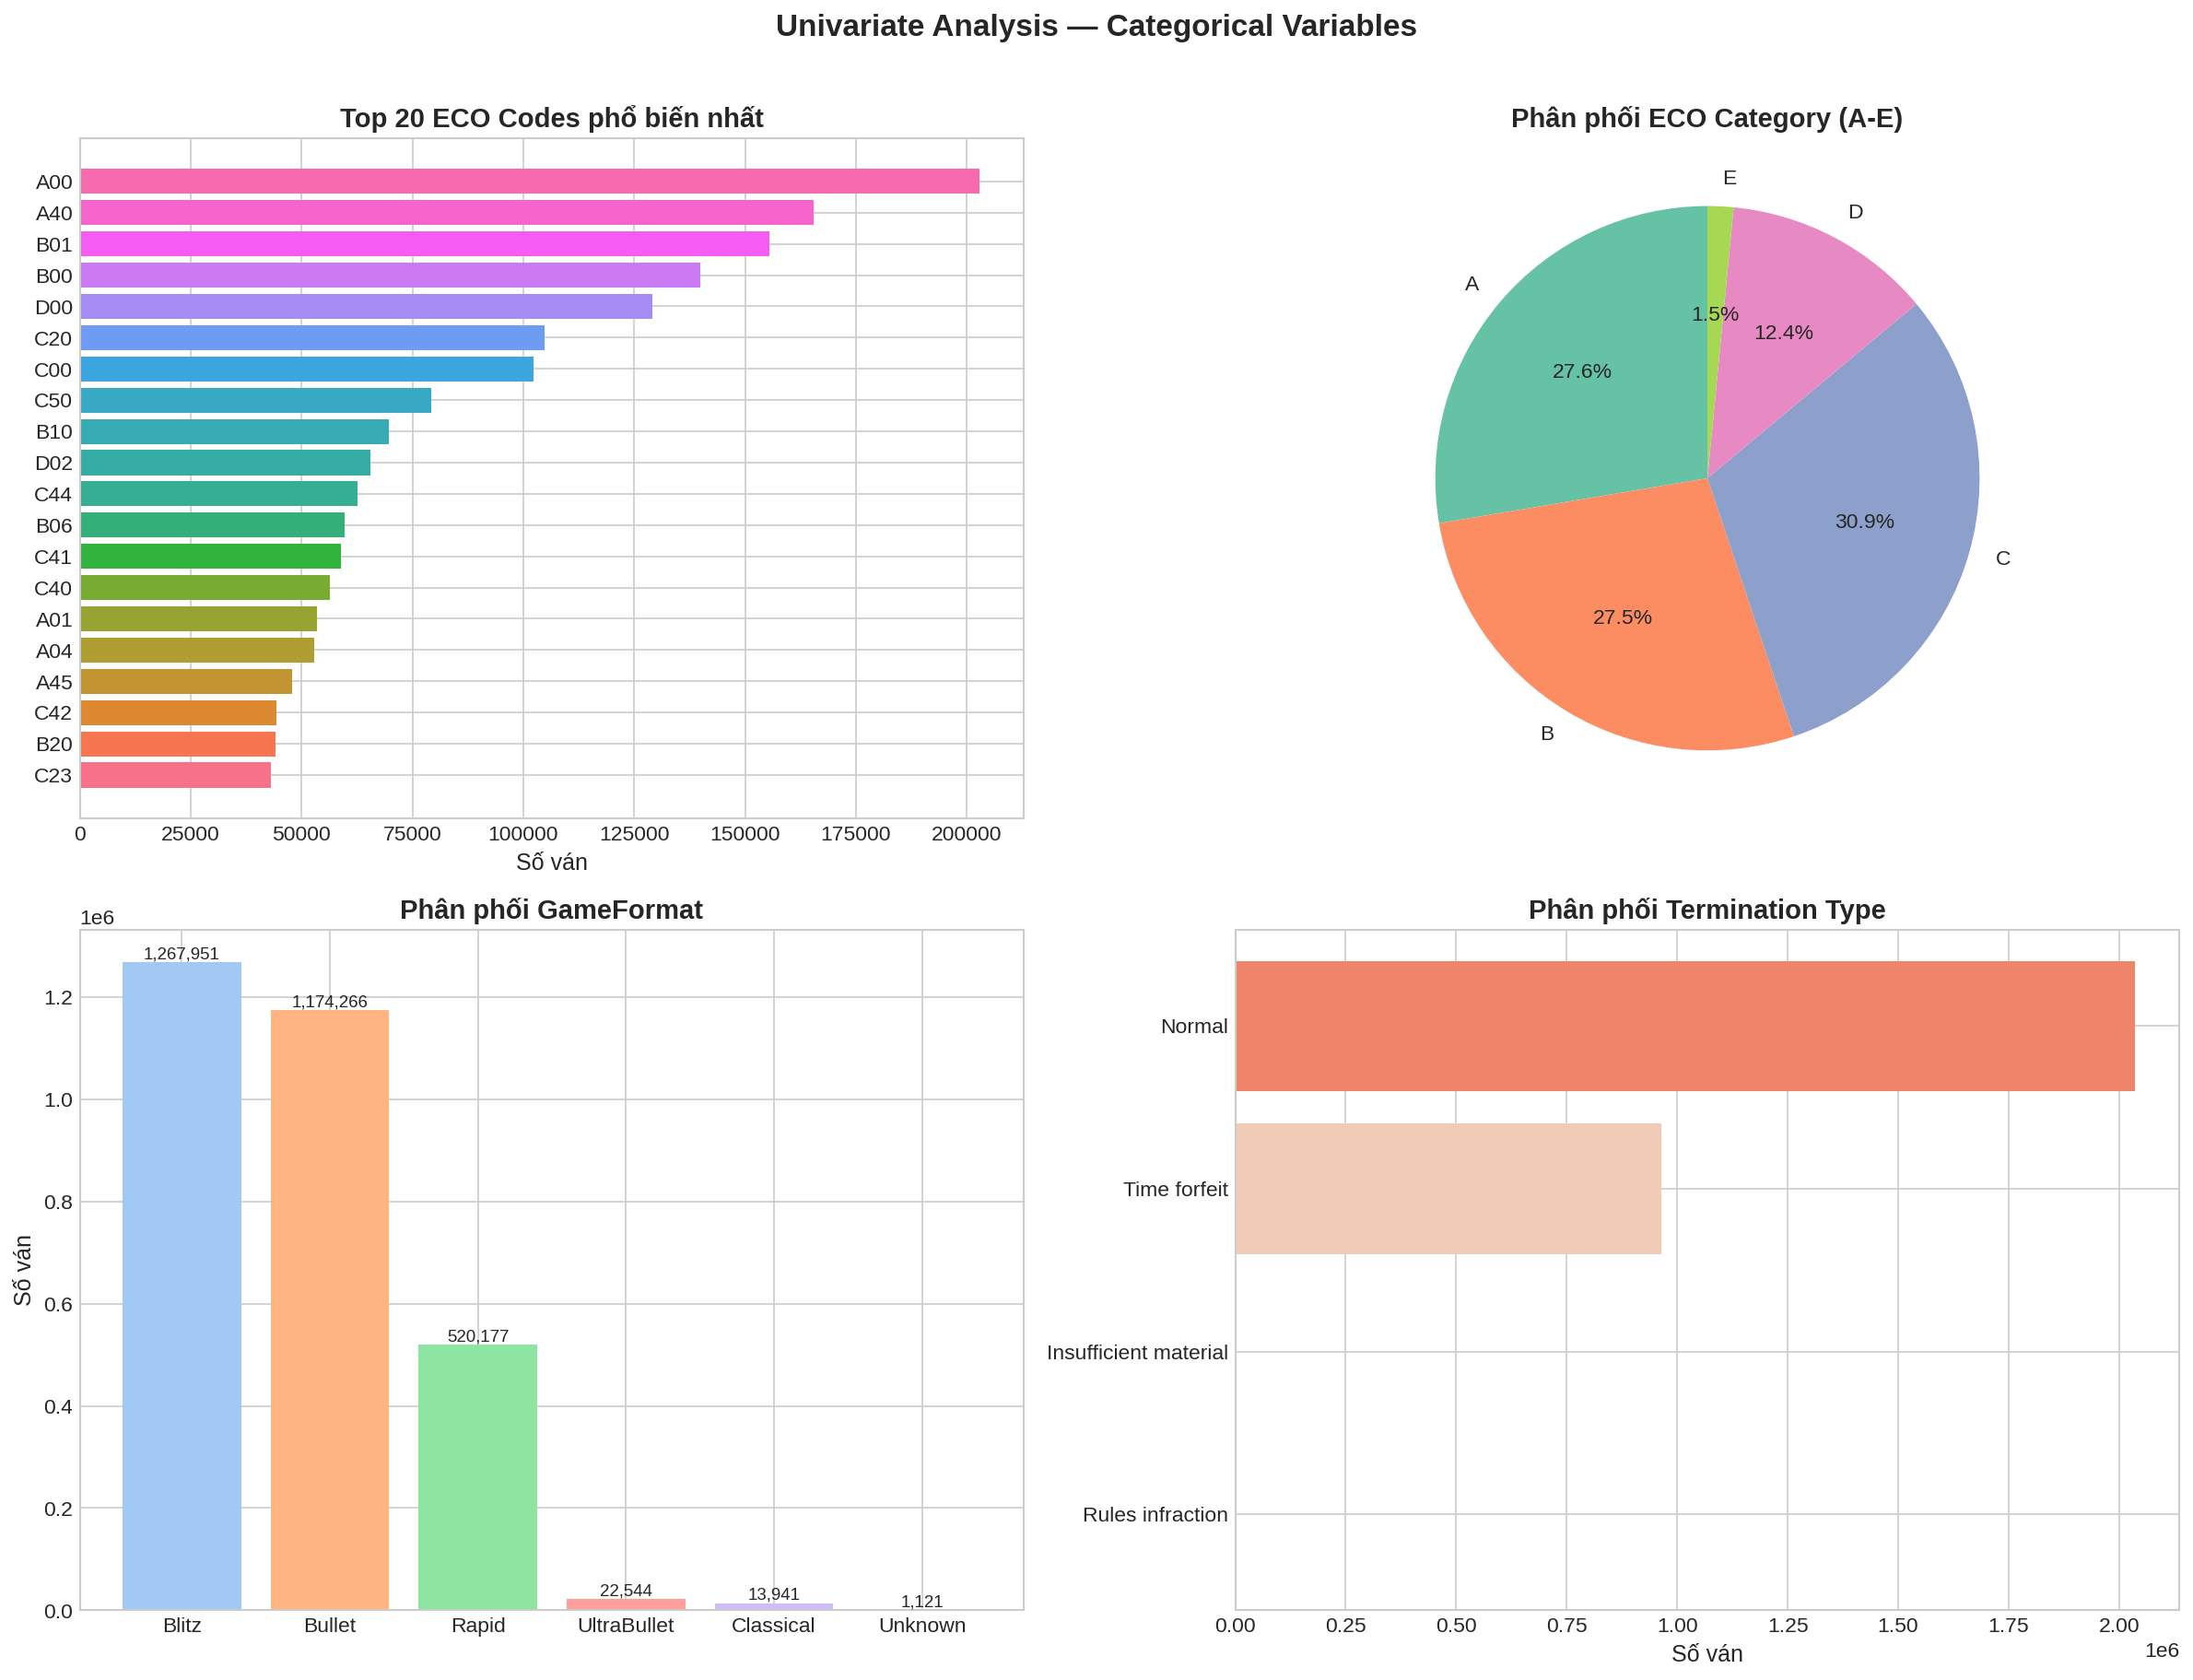

In [9]:
# ── 2.3 Phân phối ECO, GameFormat, Termination ──────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Top 20 ECO codes
eco_counts = (
    df_sample.group_by("ECO")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(20)
)
axes[0, 0].barh(eco_counts["ECO"].cast(pl.Utf8).to_list()[::-1],
                eco_counts["count"].to_list()[::-1],
                color=sns.color_palette("husl", 20))
axes[0, 0].set_title('Top 20 ECO Codes phổ biến nhất', fontweight='bold')
axes[0, 0].set_xlabel('Số ván')

# (b) ECO Category (A-E)
eco_cat_counts = (
    df_sample.group_by("EcoCategory")
    .agg(pl.len().alias("count"))
    .sort("EcoCategory")
)
wedges, texts, autotexts = axes[0, 1].pie(
    eco_cat_counts["count"].to_list(),
    labels=eco_cat_counts["EcoCategory"].to_list(),
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette("Set2", 5)
)
axes[0, 1].set_title('Phân phối ECO Category (A-E)', fontweight='bold')

# (c) GameFormat
gf_counts = (
    df_sample.group_by("GameFormat")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
bars = axes[1, 0].bar(gf_counts["GameFormat"].cast(pl.Utf8).to_list(),
                       gf_counts["count"].to_list(),
                       color=sns.color_palette("pastel", len(gf_counts)))
for bar in bars:
    h = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, h, f'{h:,.0f}',
                    ha='center', va='bottom', fontsize=9)
axes[1, 0].set_title('Phân phối GameFormat', fontweight='bold')
axes[1, 0].set_ylabel('Số ván')

# (d) Termination
term_counts = (
    df_sample.group_by("Termination")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
axes[1, 1].barh(term_counts["Termination"].cast(pl.Utf8).to_list()[::-1],
                term_counts["count"].to_list()[::-1],
                color=sns.color_palette("coolwarm", len(term_counts)))
axes[1, 1].set_title('Phân phối Termination Type', fontweight='bold')
axes[1, 1].set_xlabel('Số ván')

fig.suptitle('Univariate Analysis — Categorical Variables', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()
save_plot(fig, "03_categorical_distributions")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/04_nummoves_result.png


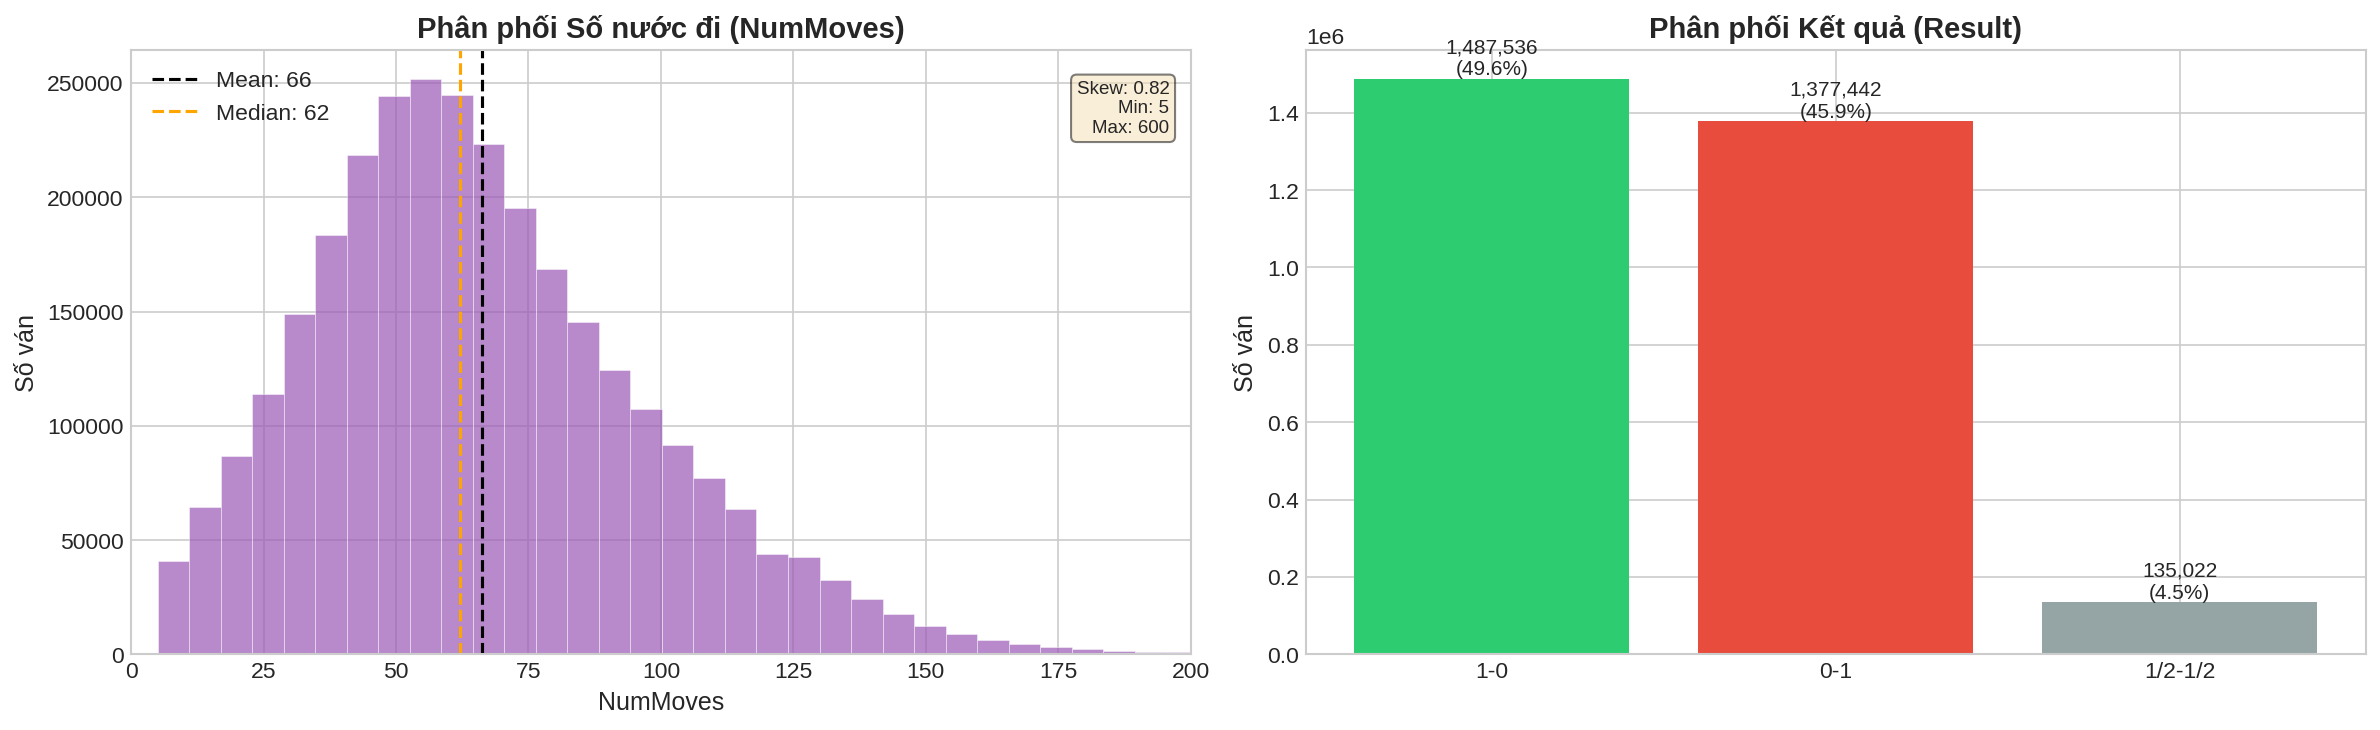

In [10]:
# ── 2.4 Phân phối NumMoves + Result ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) NumMoves histogram
num_moves = df_sample['NumMoves'].to_numpy()
axes[0].hist(num_moves, bins=100, color='#9b59b6', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[0].axvline(np.mean(num_moves), color='black', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(num_moves):.0f}')
axes[0].axvline(np.median(num_moves), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {np.median(num_moves):.0f}')
axes[0].set_title('Phân phối Số nước đi (NumMoves)', fontweight='bold')
axes[0].set_xlabel('NumMoves')
axes[0].set_ylabel('Số ván')
axes[0].legend()
axes[0].set_xlim(0, 200)

# Thống kê
skew_nm = stats.skew(num_moves)
axes[0].text(0.98, 0.95, f'Skew: {skew_nm:.2f}\nMin: {num_moves.min()}\nMax: {num_moves.max()}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# (b) Result distribution
result_counts = (
    df_sample.group_by("Result")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
colors_result = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[1].bar(result_counts["Result"].cast(pl.Utf8).to_list(),
            result_counts["count"].to_list(),
            color=colors_result[:len(result_counts)])
for i, (result, count) in enumerate(zip(result_counts["Result"].to_list(), result_counts["count"].to_list())):
    pct = count / len(df_sample) * 100
    axes[1].text(i, count, f'{count:,.0f}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Phân phối Kết quả (Result)', fontweight='bold')
axes[1].set_ylabel('Số ván')

fig.tight_layout()
save_plot(fig, "04_nummoves_result")
plt.show()

### 📊 Insight: Univariate Analysis

**Quan sát**:
- Phân phối ELO có dạng gần chuẩn (bell curve), tập trung khoảng 1200-1600
- WhiteElo và BlackElo có phân phối gần giống nhau (matchmaking hệ thống)
- GameFormat: Bullet và Blitz chiếm đa số (> 80%) — Rapid và Classical hiếm hơn
- ECO code phân bố không đều — một số khai cuộc rất phổ biến (B20, C20, A00...)

**Ý nghĩa cho mô hình**:
- Phân phối ELO chuẩn → không cần transform đặc biệt cho regression
- Bands dưới 800 và trên 2500 ít dữ liệu → cần stratified sampling hoặc class weights
- GameFormat khác nhau → nên xem xét tách model theo format hoặc dùng format làm feature
- Sự khác biệt ECO theo ELO sẽ được phân tích kỹ hơn ở Phase 3

---
# Phase 3 — Bivariate & Multivariate Analysis
> Phân tích mối quan hệ giữa các biến. **Trọng tâm**: ECO × ELO (validate giả thuyết "opening choice ≈ ELO proxy")  
> Câu hỏi: Khai cuộc có khác nhau theo trình độ? EloDiff predict kết quả tốt thế nào?

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/05_eco_elo_heatmap.png


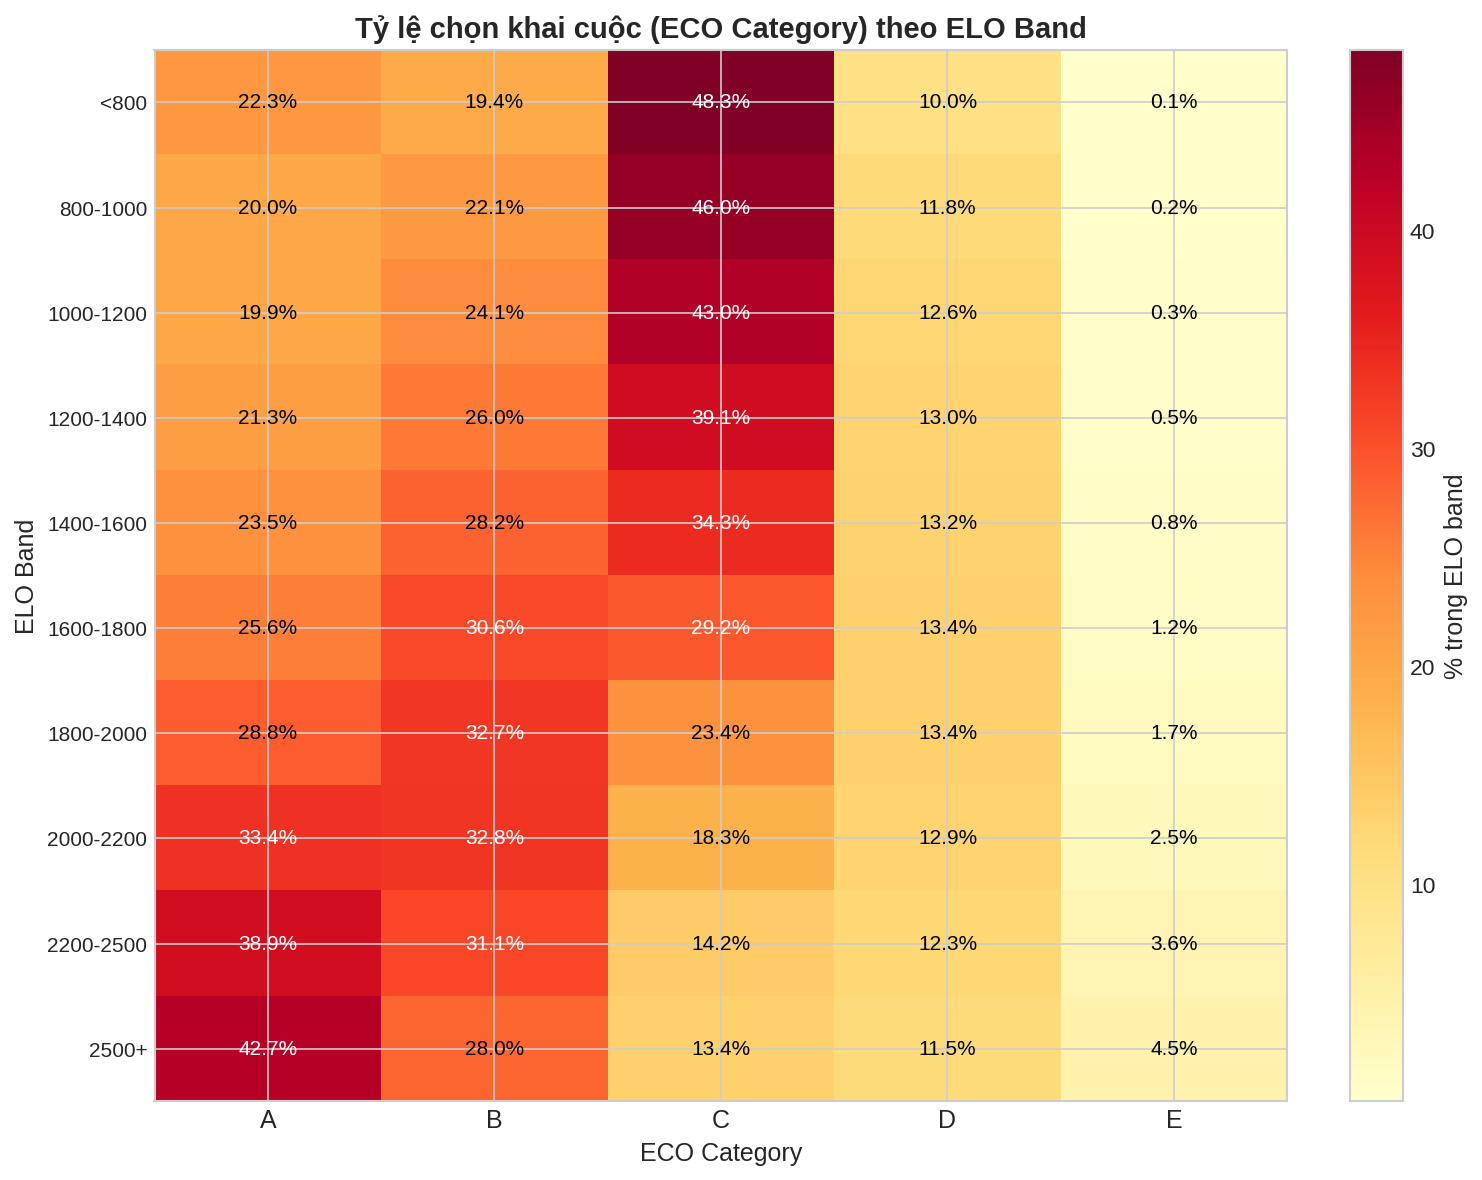

In [11]:
# ── 3.1 Heatmap: ECO Category (A-E) × ELO Band ─────────────
# Tính tỷ lệ chọn khai cuộc theo ELO band
cross_tab = (
    df_sample
    .group_by(["EloBand", "EcoCategory"])
    .agg(pl.len().alias("count"))
    .collect() if isinstance(df_sample, pl.LazyFrame) else
    df_sample
    .group_by(["EloBand", "EcoCategory"])
    .agg(pl.len().alias("count"))
)

# Pivot thành matrix
pivot = cross_tab.pivot(on="EcoCategory", index="EloBand", values="count").fill_null(0)

# Sắp xếp theo thứ tự ELO
band_order_map = {label: i for i, label in enumerate(ELO_LABELS)}
pivot = pivot.with_columns(
    pl.col("EloBand").cast(pl.Utf8).replace(band_order_map).cast(pl.Int32).alias("order")
).sort("order").drop("order")

# Normalize theo row (tỷ lệ %)
eco_cats = sorted([c for c in pivot.columns if c != "EloBand"])
matrix = pivot.select(eco_cats).to_numpy().astype(float)
row_sums = matrix.sum(axis=1, keepdims=True)
matrix_pct = matrix / row_sums * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix_pct, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(eco_cats)))
ax.set_xticklabels(eco_cats, fontsize=12)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot["EloBand"].cast(pl.Utf8).to_list(), fontsize=10)

# Annotate
for i in range(matrix_pct.shape[0]):
    for j in range(matrix_pct.shape[1]):
        val = matrix_pct[i, j]
        color = 'white' if val > matrix_pct.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=10)

ax.set_title('Tỷ lệ chọn khai cuộc (ECO Category) theo ELO Band', fontweight='bold', fontsize=14)
ax.set_xlabel('ECO Category', fontsize=12)
ax.set_ylabel('ELO Band', fontsize=12)
fig.colorbar(im, ax=ax, label='% trong ELO band', fraction=0.046)
fig.tight_layout()
save_plot(fig, "05_eco_elo_heatmap")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/06_eco_low_vs_high_elo.png


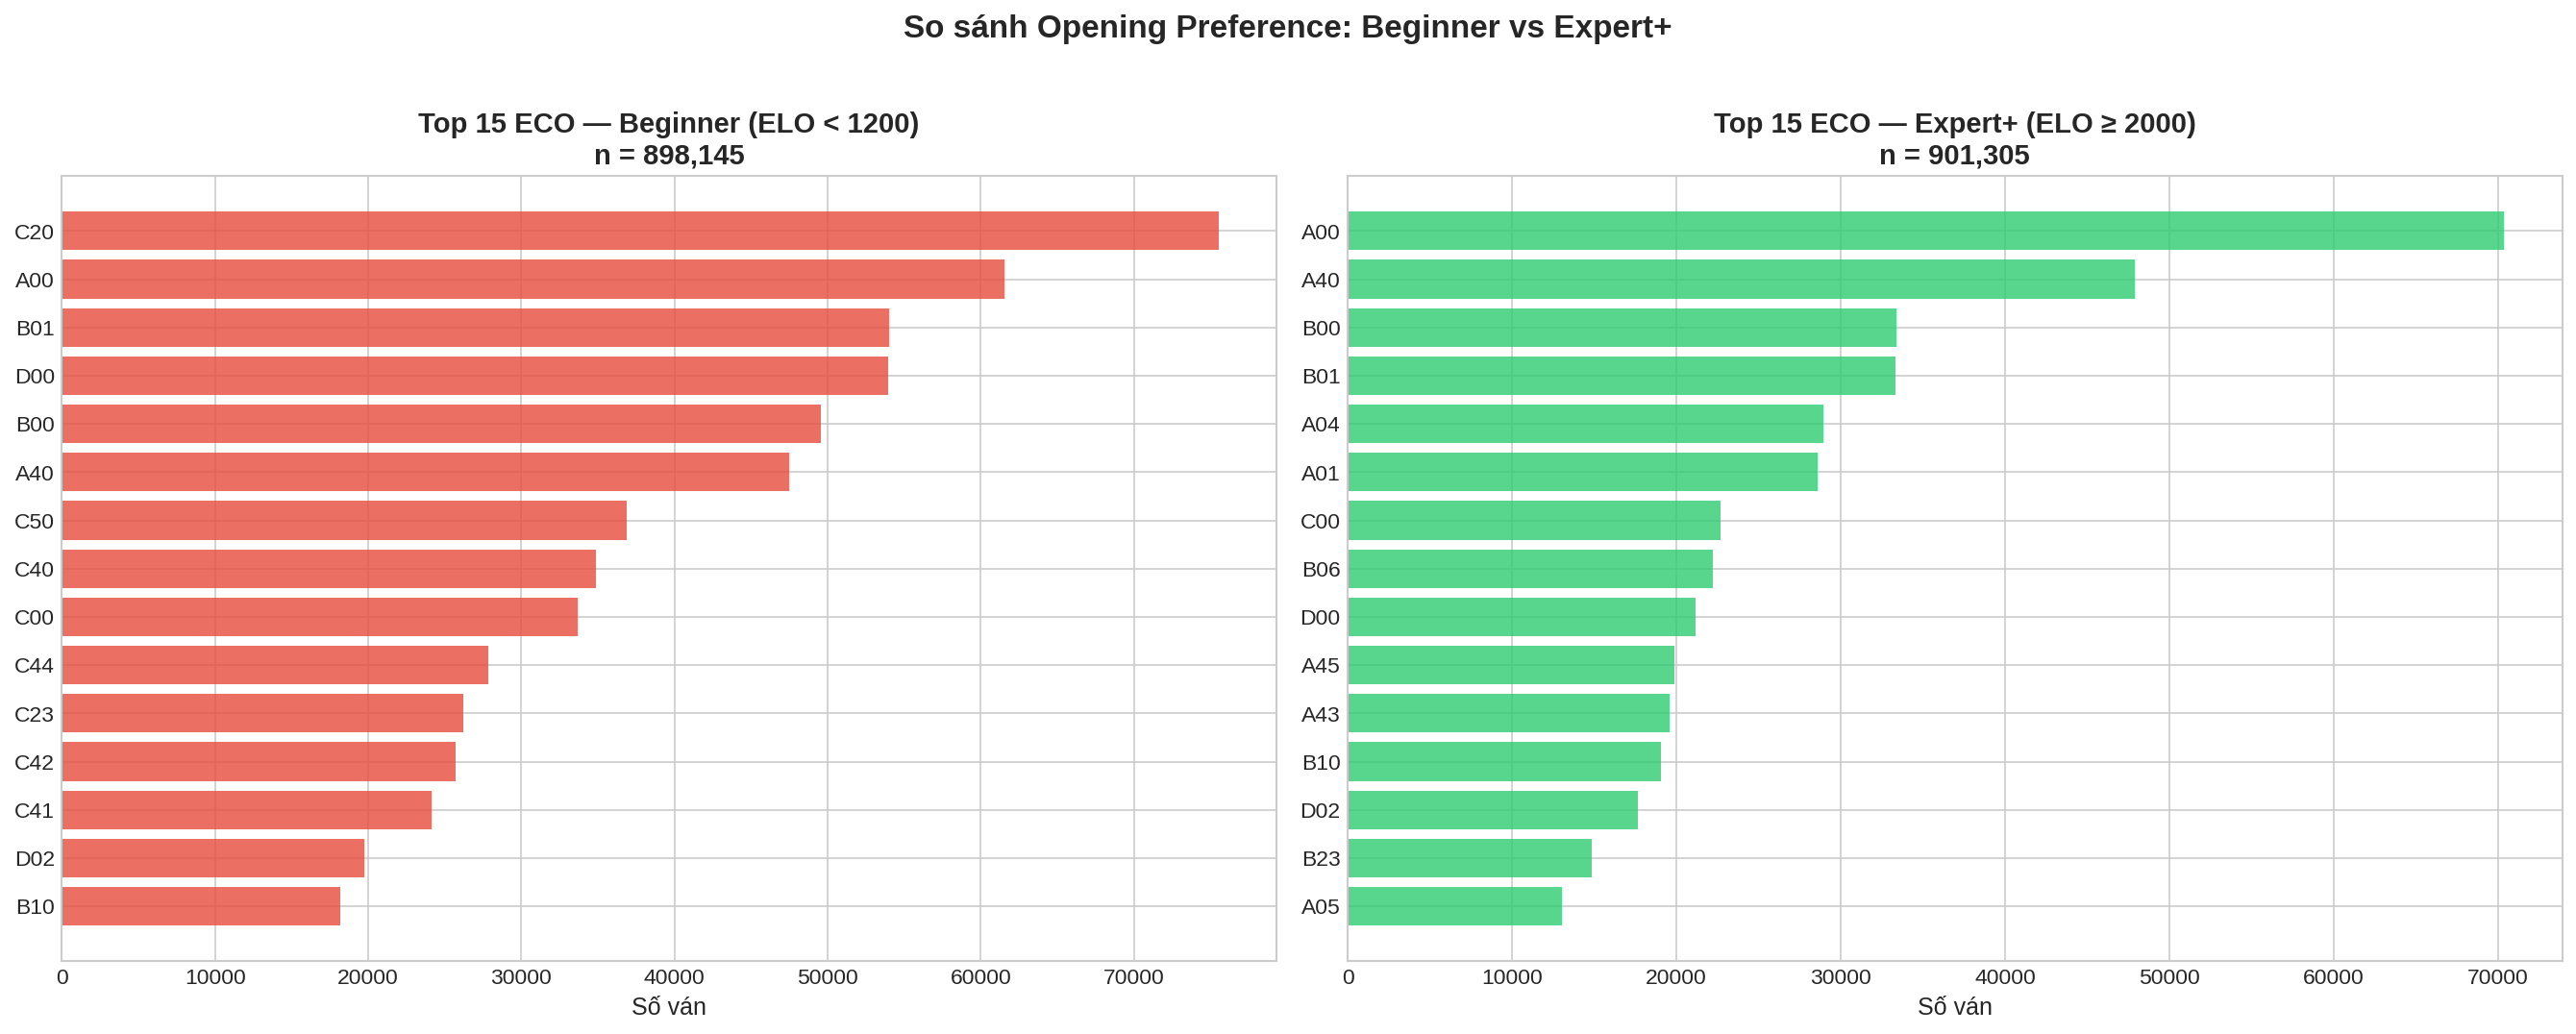

  ECO chỉ phổ biến ở Low ELO:  {'C40', 'C42', 'C23', 'C44', 'C41', 'C20', 'C50'}
  ECO chỉ phổ biến ở High ELO: {'A04', 'A01', 'B06', 'A43', 'B23', 'A05', 'A45'}
  ECO phổ biến ở cả hai:       {'D02', 'B01', 'A00', 'D00', 'C00', 'B00', 'A40', 'B10'}


In [12]:
# ── 3.2 Top ECO codes: Low ELO vs High ELO ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Low ELO: < 1200
low_elo = df_sample.filter(pl.col("EloAvg") < 1200)
low_eco = (
    low_elo.group_by("ECO")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(15)
)

# High ELO: >= 2000
high_elo = df_sample.filter(pl.col("EloAvg") >= 2000)
high_eco = (
    high_elo.group_by("ECO")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(15)
)

# Plot
axes[0].barh(low_eco["ECO"].cast(pl.Utf8).to_list()[::-1],
             low_eco["count"].to_list()[::-1],
             color='#e74c3c', alpha=0.8)
axes[0].set_title(f'Top 15 ECO — Beginner (ELO < 1200)\nn = {len(low_elo):,}', fontweight='bold')
axes[0].set_xlabel('Số ván')

axes[1].barh(high_eco["ECO"].cast(pl.Utf8).to_list()[::-1],
             high_eco["count"].to_list()[::-1],
             color='#2ecc71', alpha=0.8)
axes[1].set_title(f'Top 15 ECO — Expert+ (ELO ≥ 2000)\nn = {len(high_elo):,}', fontweight='bold')
axes[1].set_xlabel('Số ván')

fig.suptitle('So sánh Opening Preference: Beginner vs Expert+', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
save_plot(fig, "06_eco_low_vs_high_elo")
plt.show()

# In ra sự khác biệt
low_set = set(low_eco["ECO"].cast(pl.Utf8).to_list())
high_set = set(high_eco["ECO"].cast(pl.Utf8).to_list())
print(f"  ECO chỉ phổ biến ở Low ELO:  {low_set - high_set}")
print(f"  ECO chỉ phổ biến ở High ELO: {high_set - low_set}")
print(f"  ECO phổ biến ở cả hai:       {low_set & high_set}")

/tmp/ipykernel_90833/2336761423.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_eco, labels=top_eco, patch_artist=True, showfliers=False,


  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/07_eco_elo_boxplot.png


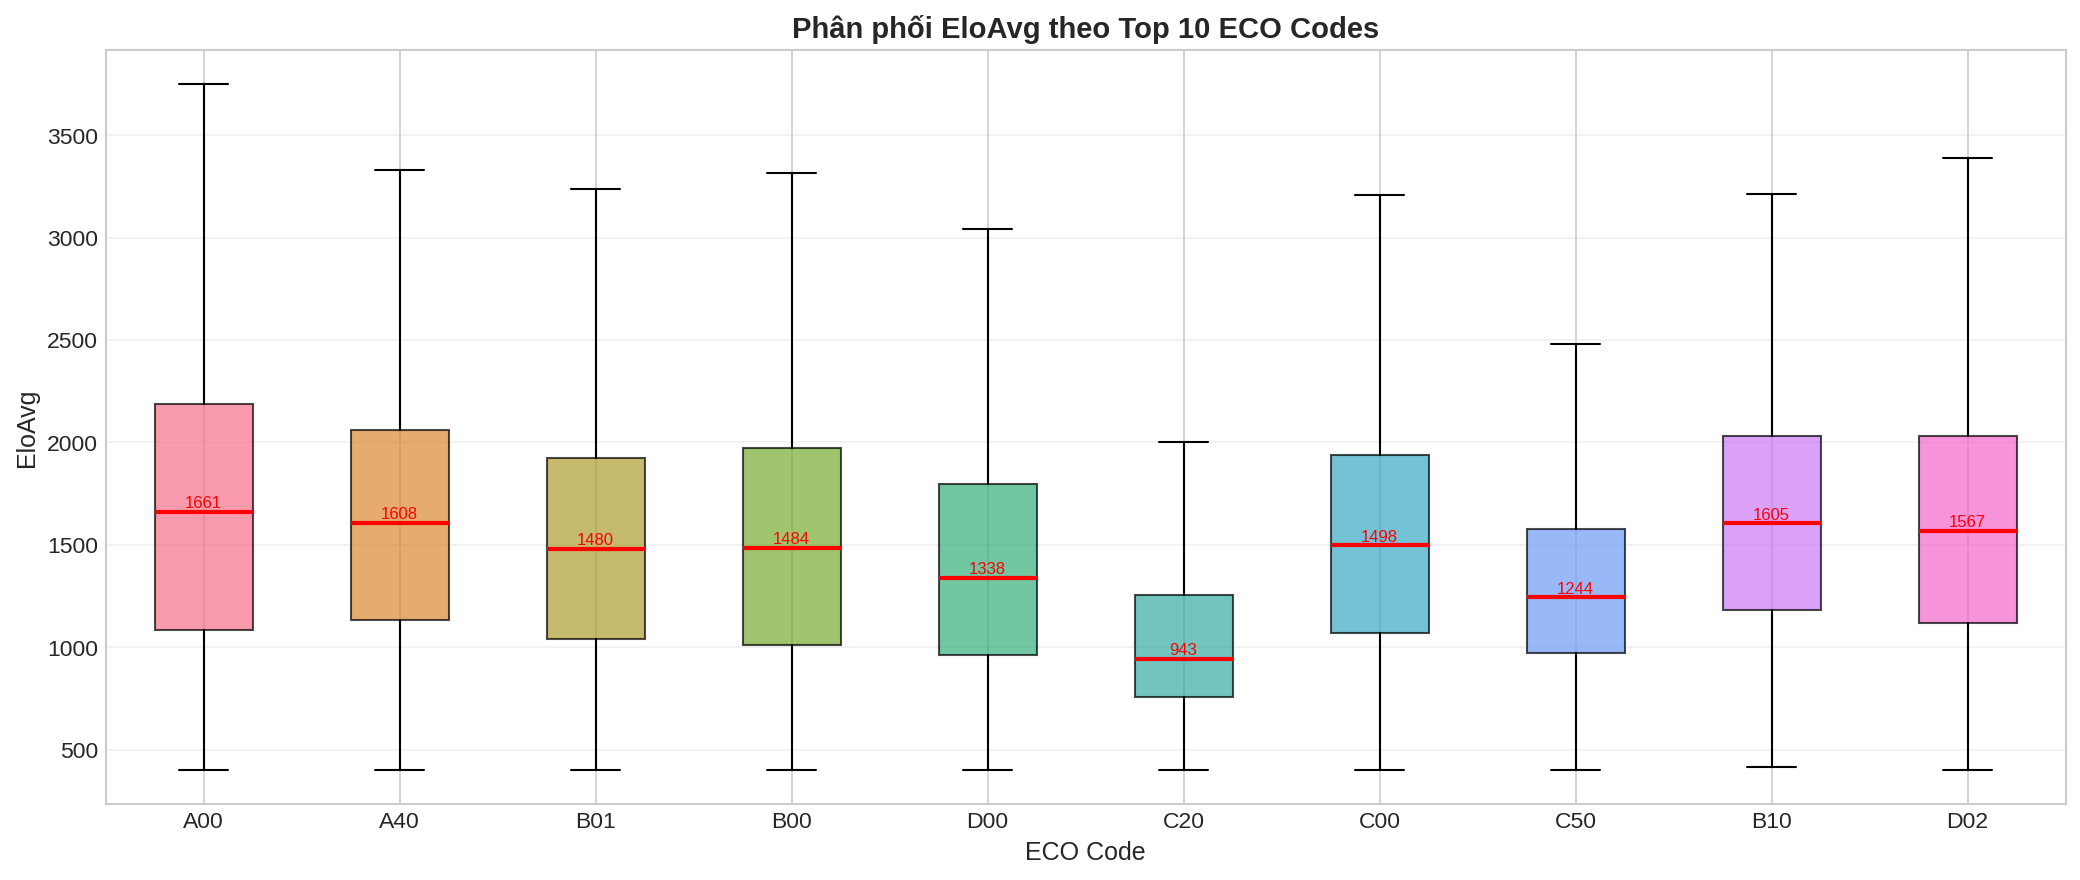

In [13]:
# ── 3.3 EloAvg distribution cho Top 10 ECO codes ────────────
top_eco = (
    df_sample.group_by("ECO")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
    ["ECO"].cast(pl.Utf8).to_list()
)

fig, ax = plt.subplots(figsize=(14, 6))
data_eco = []
for eco in top_eco:
    vals = df_sample.filter(pl.col("ECO").cast(pl.Utf8) == eco)["EloAvg"].to_list()
    data_eco.append(vals)

bp = ax.boxplot(data_eco, labels=top_eco, patch_artist=True, showfliers=False,
                medianprops=dict(color='red', linewidth=2))
palette = sns.color_palette("husl", 10)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Phân phối EloAvg theo Top 10 ECO Codes', fontweight='bold')
ax.set_xlabel('ECO Code')
ax.set_ylabel('EloAvg')
ax.grid(axis='y', alpha=0.3)

# Annotate median
for i, eco in enumerate(top_eco):
    median_val = np.median(data_eco[i])
    ax.text(i + 1, median_val + 20, f'{median_val:.0f}', ha='center', fontsize=8, color='red')

fig.tight_layout()
save_plot(fig, "07_eco_elo_boxplot")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/08_elodiff_winrate.png


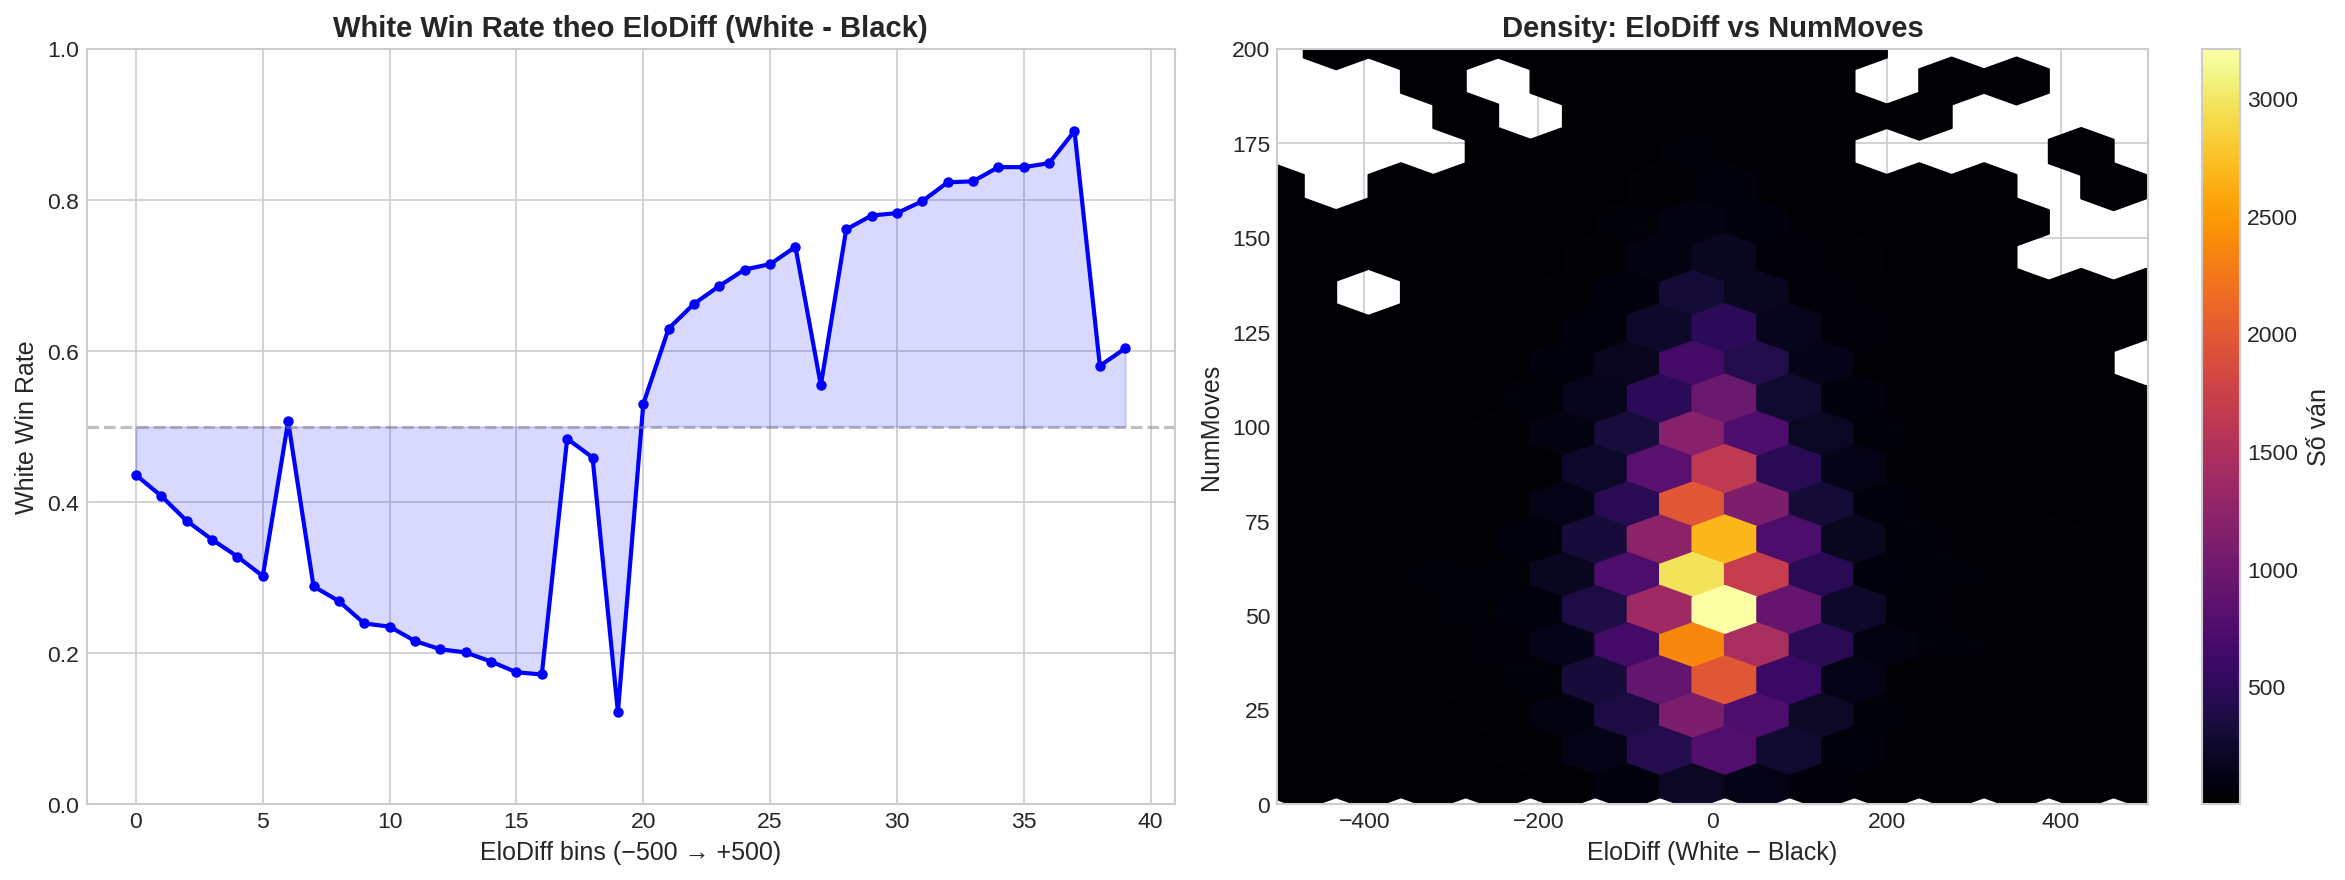

In [14]:
# ── 3.4 EloDiff × Win Rate (baseline understanding) ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Line plot: Win rate theo EloDiff (continuous bins)
diff_bins = np.arange(-500, 501, 25)
df_wr2 = df_sample.with_columns(
    pl.col("EloDiff").clip(-500, 500)
      .cut(diff_bins[1:].tolist())
      .alias("DiffBin")
)
wr_continuous = (
    df_wr2.group_by("DiffBin")
    .agg([
        pl.col("ResultNumeric").mean().alias("WhiteWR"),
        pl.len().alias("n"),
    ])
    .sort("DiffBin")
    .filter(pl.col("n") > 100)
)

x_vals = list(range(len(wr_continuous)))
y_vals = wr_continuous["WhiteWR"].to_list()
n_vals = wr_continuous["n"].to_list()

axes[0].plot(x_vals, y_vals, 'b-o', markersize=4, linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_between(x_vals, 0.5, y_vals, alpha=0.15, color='blue')
axes[0].set_title('White Win Rate theo EloDiff (White - Black)', fontweight='bold')
axes[0].set_xlabel('EloDiff bins (−500 → +500)')
axes[0].set_ylabel('White Win Rate')
axes[0].set_ylim(0, 1)

# (b) 2D Density: EloDiff vs NumMoves
# Sample subset cho scatter
scatter_sample = df_sample.sample(n=min(50_000, len(df_sample)), seed=42)
axes[1].hexbin(
    scatter_sample["EloDiff"].to_numpy(),
    scatter_sample["NumMoves"].to_numpy(),
    gridsize=40, cmap='inferno', mincnt=1
)
axes[1].set_title('Density: EloDiff vs NumMoves', fontweight='bold')
axes[1].set_xlabel('EloDiff (White − Black)')
axes[1].set_ylabel('NumMoves')
axes[1].set_xlim(-500, 500)
axes[1].set_ylim(0, 200)
fig.colorbar(axes[1].collections[0], ax=axes[1], label='Số ván')

fig.tight_layout()
save_plot(fig, "08_elodiff_winrate")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/09_correlation_matrix.png


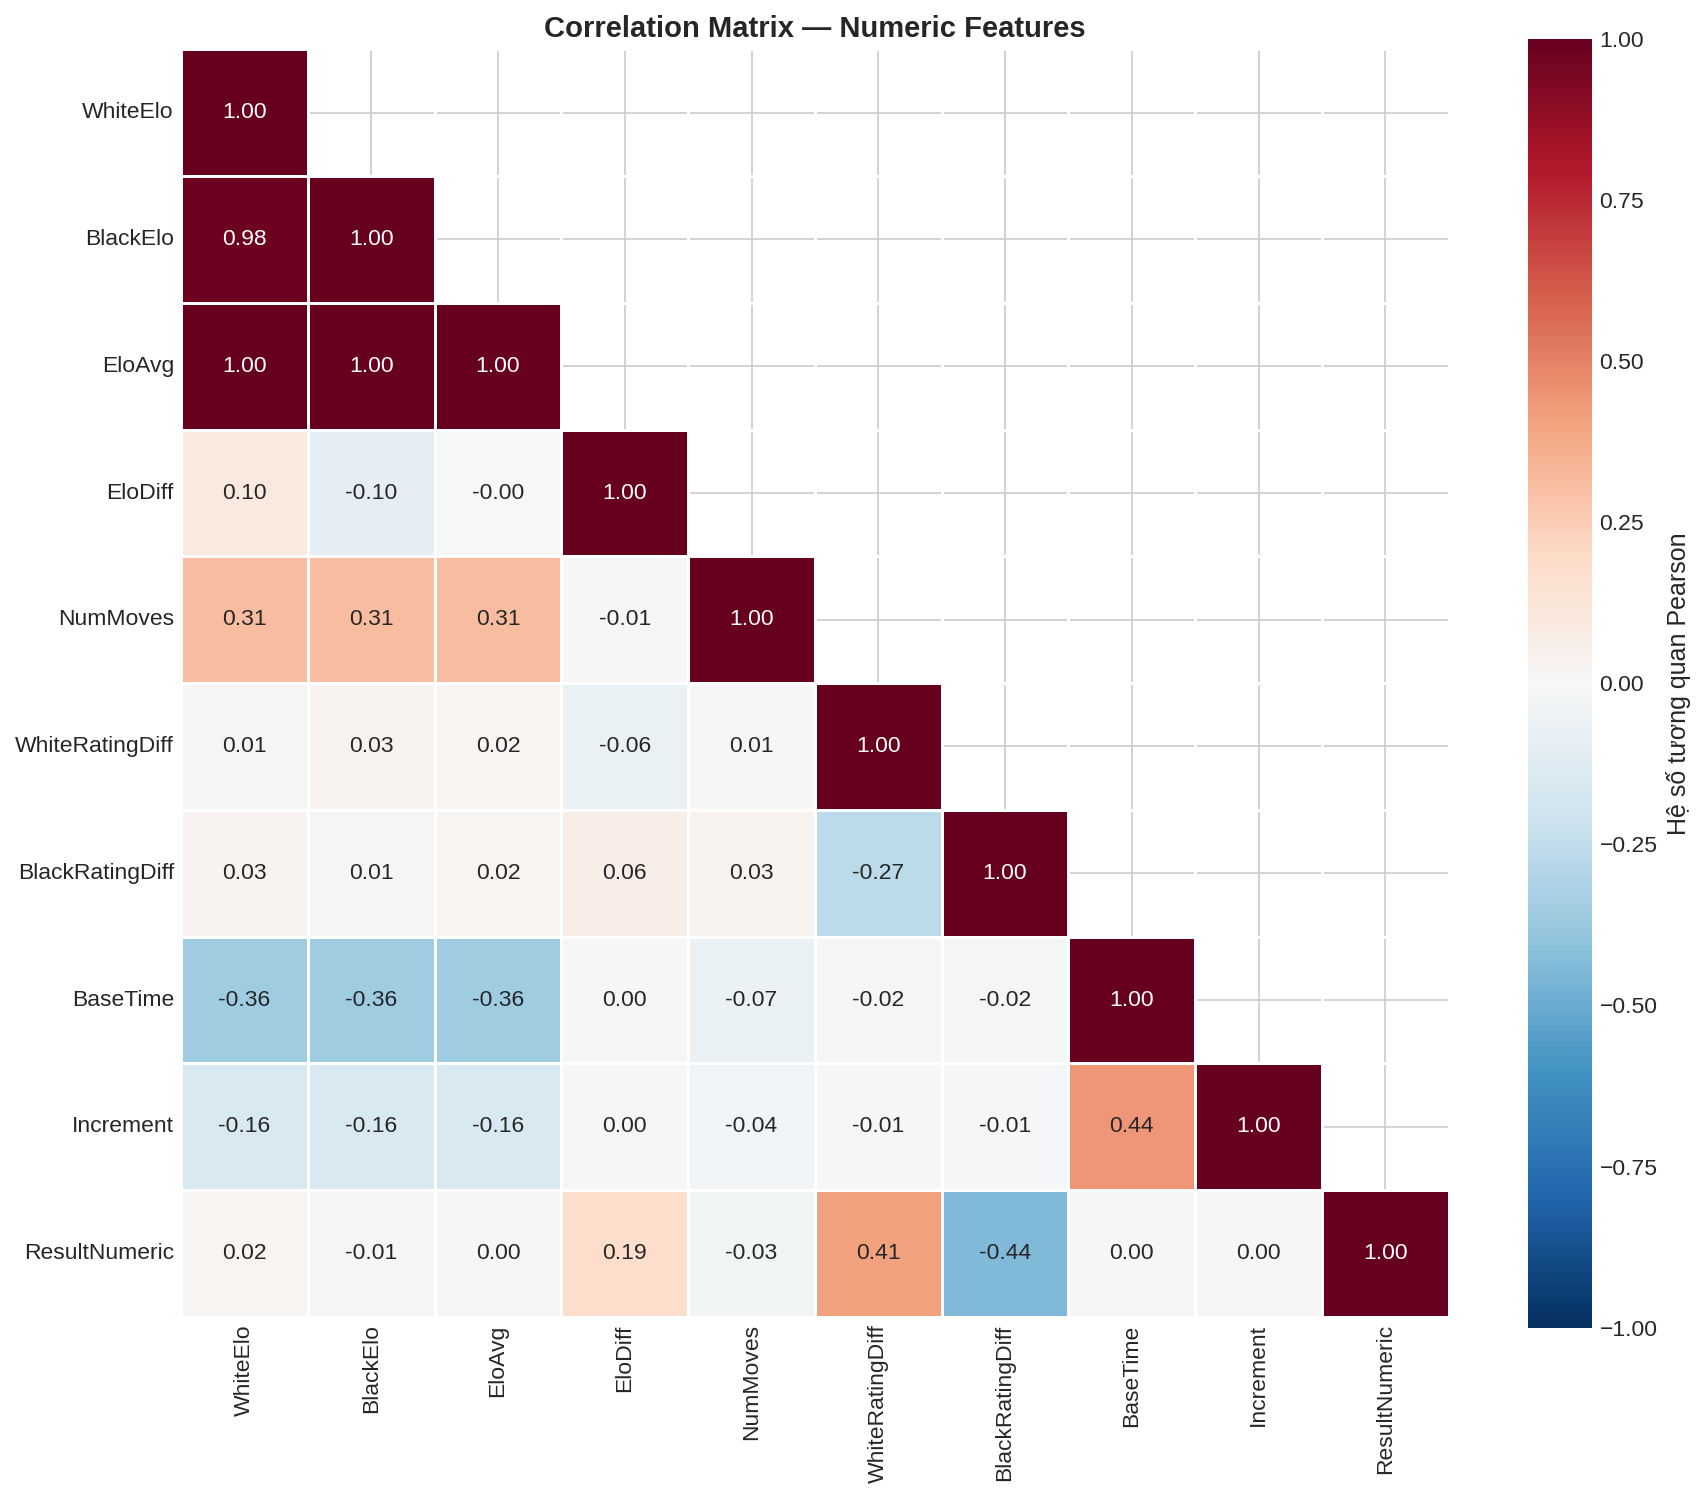

📊 Top correlations với EloAvg:
  BaseTime                  r = -0.3590
  NumMoves                  r = +0.3081
  Increment                 r = -0.1640
  WhiteRatingDiff           r = +0.0195
  BlackRatingDiff           r = +0.0193
  ResultNumeric             r = +0.0032
  EloDiff                   r = -0.0007


In [15]:
# ── 3.5 Correlation Matrix — Numeric Features ───────────────
numeric_features = ['WhiteElo', 'BlackElo', 'EloAvg', 'EloDiff', 'NumMoves',
                    'WhiteRatingDiff', 'BlackRatingDiff', 'BaseTime', 'Increment',
                    'ResultNumeric']

corr_df = df_sample.select(numeric_features).to_pandas()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Hệ số tương quan Pearson'})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=14)
fig.tight_layout()
save_plot(fig, "09_correlation_matrix")
plt.show()

# In top correlations với EloAvg (trừ White/BlackElo)
print("📊 Top correlations với EloAvg:")
elo_corr = corr_matrix['EloAvg'].drop(['EloAvg', 'WhiteElo', 'BlackElo']).sort_values(key=abs, ascending=False)
for feat, val in elo_corr.items():
    print(f"  {feat:<25} r = {val:+.4f}")

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/10_nummoves_format_elo.png


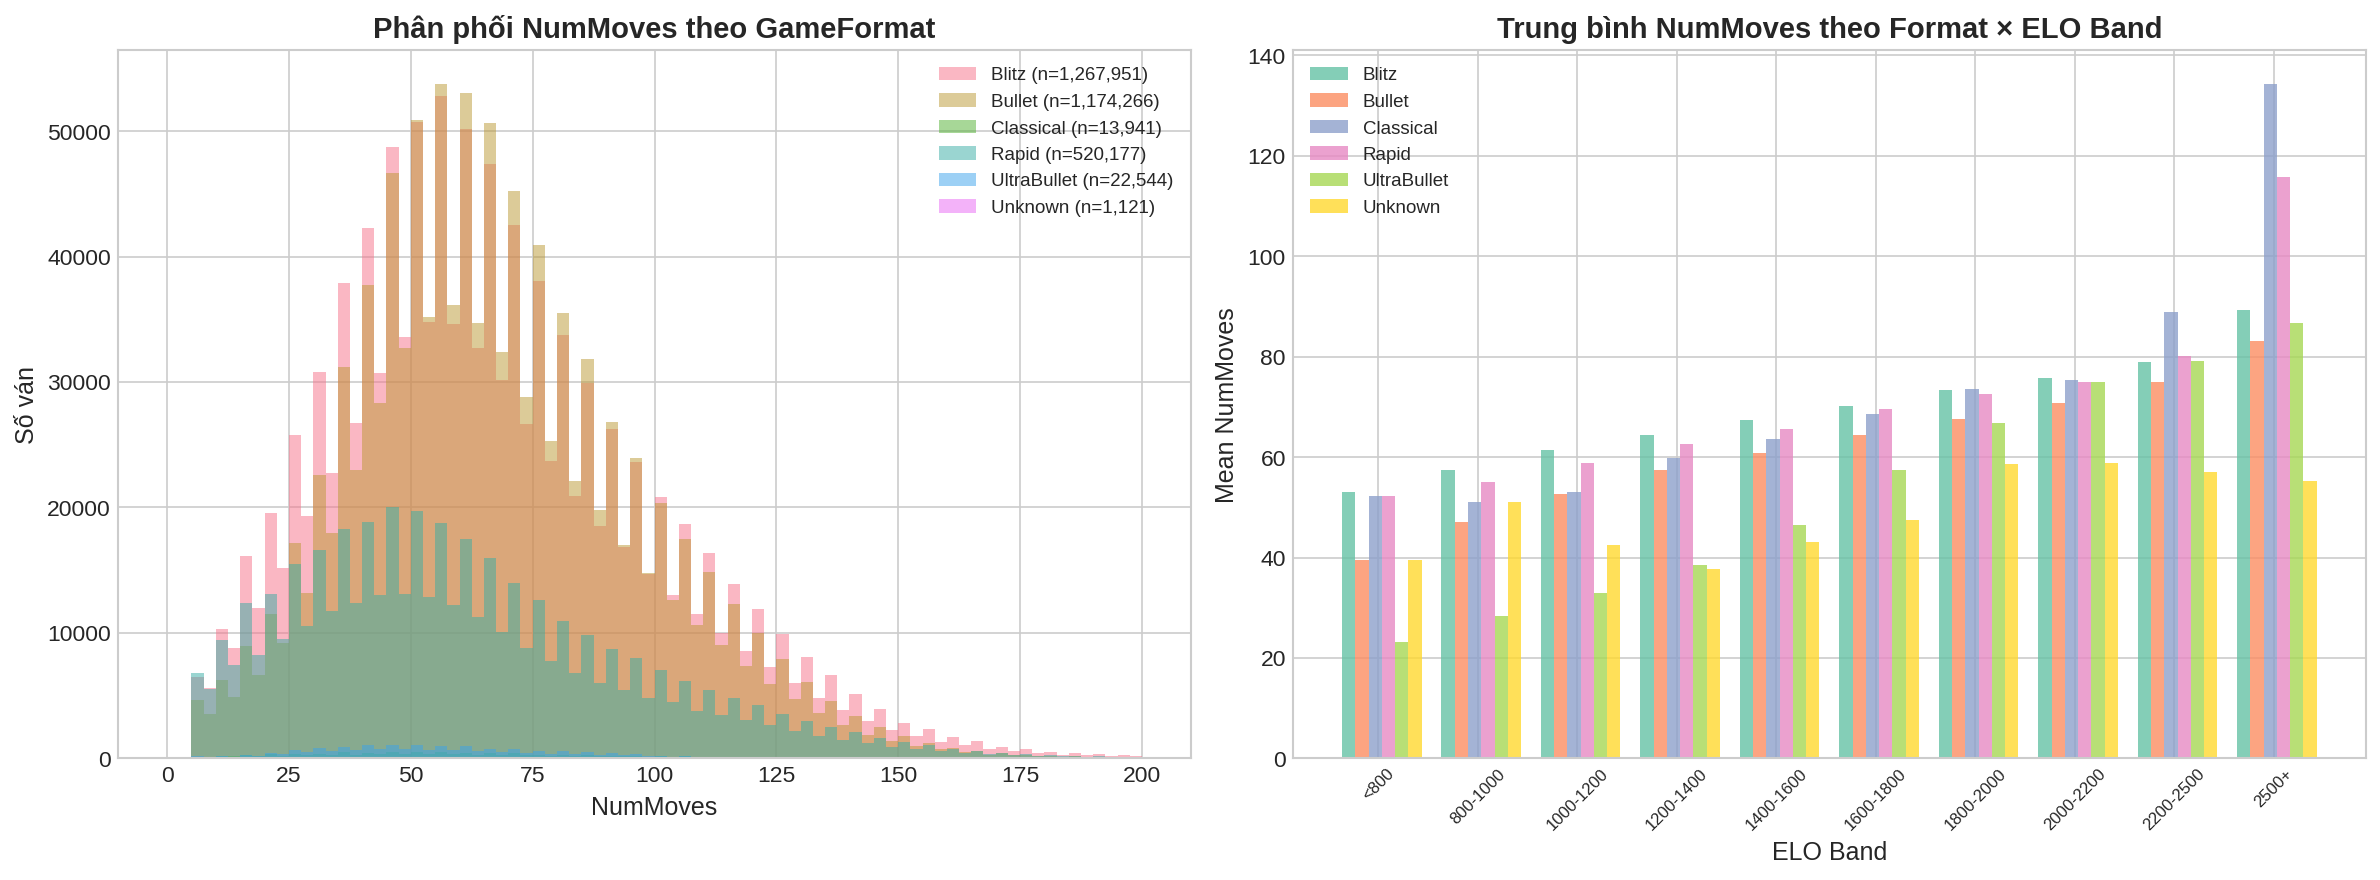

In [16]:
# ── 3.6 NumMoves và ELO theo GameFormat ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

formats = df_sample["GameFormat"].cast(pl.Utf8).unique().sort().to_list()
palette_fmt = dict(zip(formats, sns.color_palette("Set2", len(formats))))

# (a) NumMoves distribution theo GameFormat + ELO Band
for fmt in formats:
    subset = df_sample.filter(pl.col("GameFormat").cast(pl.Utf8) == fmt)
    axes[0].hist(subset["NumMoves"].to_numpy(), bins=80, alpha=0.5,
                 label=f'{fmt} (n={len(subset):,})', range=(0, 200))
axes[0].set_title('Phân phối NumMoves theo GameFormat', fontweight='bold')
axes[0].set_xlabel('NumMoves')
axes[0].set_ylabel('Số ván')
axes[0].legend(fontsize=9)

# (b) Mean NumMoves theo GameFormat × EloBand
# Pivot để đảm bảo tất cả bands đều có giá trị (fill 0 nếu thiếu)
fmt_elo = (
    df_sample.group_by(["GameFormat", "EloBand"])
    .agg([
        pl.col("NumMoves").mean().alias("MeanMoves"),
        pl.len().alias("count"),
    ])
)

for i, fmt in enumerate(formats):
    subset = fmt_elo.filter(pl.col("GameFormat").cast(pl.Utf8) == fmt)
    # Map EloBand → order index, đảm bảo đầy đủ tất cả bands
    elo_order = {label: j for j, label in enumerate(ELO_LABELS)}
    subset = subset.with_columns(
        pl.col("EloBand").cast(pl.Utf8).replace(
            {label: str(j) for j, label in enumerate(ELO_LABELS)}
        ).cast(pl.Int32).alias("order")
    ).sort("order")
    
    # Tạo array đầy đủ cho tất cả ELO bands, fill NaN nếu band không có data
    mean_moves_full = [None] * len(ELO_LABELS)
    for row in subset.iter_rows(named=True):
        idx = row["order"]
        mean_moves_full[idx] = row["MeanMoves"]
    
    x = np.arange(len(ELO_LABELS))
    width = 0.8 / len(formats)
    axes[1].bar(x + i * width,
                [v if v is not None else 0 for v in mean_moves_full],
                width=width, label=fmt, color=palette_fmt[fmt], alpha=0.8)

axes[1].set_title('Trung bình NumMoves theo Format × ELO Band', fontweight='bold')
axes[1].set_xlabel('ELO Band')
axes[1].set_ylabel('Mean NumMoves')
axes[1].set_xticks(np.arange(len(ELO_LABELS)) + 0.3)
axes[1].set_xticklabels(ELO_LABELS, rotation=45, fontsize=8)
axes[1].legend(fontsize=9)

fig.tight_layout()
save_plot(fig, "10_nummoves_format_elo")
plt.show()

### 📊 Insight: Bivariate & Multivariate Analysis

**Quan sát ECO × ELO**:
- Tỷ lệ chọn ECO category thay đổi rõ rệt theo ELO band → **khai cuộc là tín hiệu mạnh** cho ELO prediction
- Người chơi trình độ cao có xu hướng chọn khai cuộc khác biệt so với beginner
- Một số ECO codes chỉ phổ biến ở ELO cao (thường là e4 openings phức tạp, d4 systems)

**Quan sát EloDiff × Result**:
- Win rate tương quan mạnh với EloDiff → ELO system hoạt động hiệu quả
- Sigmoid-shape: win rate tăng smoothly theo EloDiff → baseline ngầm định cho model

**Quan sát Correlation**:
- WhiteElo ↔ BlackElo correlation rất cao (matchmaking)
- NumMoves, BaseTime có thể tương quan nhẹ với EloAvg
- RatingDiff columns có thông tin về "form" của player

**Hàm ý cho mô hình**:
- ECO (khai cuộc) là feature candidate #1 cho ELO prediction
- GameFormat nên là feature hoặc dùng để tách model (vì player behavior khác nhau theo format)
- NumMoves có thể là proxy feature (higher ELO = longer games trung bình)
- Cần phân tích sâu hơn ở move-level (Phase 4) để xác nhận tín hiệu

---
# Phase 4 — Move Sequence Analysis (Critical for Model Design)
> **Trọng tâm**: Đánh giá tín hiệu ELO từ những nước đi đầu tiên.  
> Câu hỏi: Sau bao nhiêu nước, ta có đủ signal để predict ELO? Opening choice khác nhau thế nào theo trình độ?  
> Đây là phase quan trọng nhất — quyết định tính khả thi của mô hình realtime.

⚠️ **Note**: Phase này cần load cột `Moves` → sample nhỏ hơn để tiết kiệm RAM.

In [17]:
# ── 4.1 Load Moves cho sample nhỏ hơn ───────────────────────
# ⚡ OPTIMIZED: 2 partial reads (head) thay vì 10 full scans (~450GB → ~5GB I/O)
t0 = time.time()
MOVE_SAMPLE_SIZE = 500_000
move_sample_per_band = MOVE_SAMPLE_SIZE // len(ELO_LABELS)
parquet_files = sorted(DATA_PROCESSED.glob("*.parquet"))

# Mỗi file chỉ đọc 2.5M rows đầu — Parquet reader dừng sớm, cực nhanh
# 5M raw → stratify → 500K final
OVERSAMPLE_TOTAL = MOVE_SAMPLE_SIZE * 10  # 5M total raw
per_file = OVERSAMPLE_TOTAL // len(parquet_files)

print(f"⏳ Loading moves sample (~{MOVE_SAMPLE_SIZE:,} target)...")
print(f"  Strategy: read_parquet(n_rows={per_file:,}) × {len(parquet_files)} files")
print(f"  → stratify in-memory (instant)")
print(f"  CPU cores: {os.cpu_count()}")

chunks = []
for pf in parquet_files:
    t1 = time.time()
    chunk = pl.read_parquet(pf, n_rows=per_file)
    chunks.append(chunk)
    print(f"  📁 {pf.name}: {len(chunk):,} rows, ~{chunk.estimated_size('gb'):.2f} GB, {time.time()-t1:.1f}s")

df_moves_raw = pl.concat(chunks)
del chunks
gc.collect()

# Thêm EloBand + stratified subsample in-memory (instant)
df_moves_raw = df_moves_raw.with_columns(
    pl.col("EloAvg")
      .cut(ELO_BINS[1:-1], labels=ELO_LABELS)
      .alias("EloBand")
)
print(f"\n  Raw pool: {len(df_moves_raw):,} rows, ~{df_moves_raw.estimated_size('gb'):.2f} GB")

move_samples = []
for band in ELO_LABELS:
    band_df = df_moves_raw.filter(pl.col("EloBand") == band)
    n_take = min(len(band_df), move_sample_per_band)
    if n_take > 0:
        move_samples.append(band_df.sample(n=n_take, seed=RANDOM_SEED))
    print(f"  {band:<15} pool: {len(band_df):>8,}  sampled: {n_take:>6,}")

df_moves = pl.concat(move_samples).sample(fraction=1.0, seed=RANDOM_SEED)
print(f"\n✅ Moves sample: {len(df_moves):,} rows, ~{df_moves.estimated_size('gb'):.2f} GB")
print(f"  ⏱ Total time: {time.time() - t0:.1f}s")

del df_moves_raw, move_samples
gc.collect()

⏳ Loading moves sample (~500,000 target)...
  Strategy: read_parquet(n_rows=2,500,000) × 2 files
  → stratify in-memory (instant)
  CPU cores: 20
  📁 lichess_2025-12_ml.parquet: 2,500,000 rows, ~1.02 GB, 0.2s
  📁 lichess_2026-01_ml.parquet: 2,500,000 rows, ~1.03 GB, 0.2s

  Raw pool: 5,000,000 rows, ~2.06 GB
  <800            pool:   67,443  sampled: 50,000
  800-1000        pool:  206,902  sampled: 50,000
  1000-1200       pool:  408,935  sampled: 50,000
  1200-1400       pool:  623,058  sampled: 50,000
  1400-1600       pool:  845,832  sampled: 50,000
  1600-1800       pool:  967,605  sampled: 50,000
  1800-2000       pool:  894,124  sampled: 50,000
  2000-2200       pool:  578,593  sampled: 50,000
  2200-2500       pool:  332,173  sampled: 50,000
  2500+           pool:   75,335  sampled: 50,000

✅ Moves sample: 500,000 rows, ~0.20 GB
  ⏱ Total time: 0.9s


0

In [18]:
# ── 4.2 Extract First-N Moves ────────────────────────────────
# ⚡ OPTIMIZED: 100% vectorized Polars str ops thay vì map_elements (50-100× nhanh hơn)
# Polars dùng tất cả CPU cores cho str operations — tận dụng 20 threads i5-14600KF
t0 = time.time()

print("⏳ Extracting first moves (vectorized, multi-threaded)...")

# Step 1: Clean SAN string → tạo list các nước đi
# Format: "1. e4 e5 2. Nf3 Nc6 3. Bb5 a6" → ["e4", "e5", "Nf3", "Nc6", "Bb5", "a6"]
df_moves = df_moves.with_columns(
    pl.col("Moves")
    .str.replace_all(r"\d+\.\s*", "")                         # Xóa "1. ", "12. "
    .str.replace_all(r"\s*(1-0|0-1|1/2-1/2|\*)\s*$", "")      # Xóa kết quả cuối
    .str.strip_chars()
    .str.replace_all(r"\s+", " ")                              # Chuẩn hoá whitespace
    .str.split(" ")                                             # → List[Utf8]
    .alias("_move_tokens")
)

# Step 2: Extract first-N từ token list — mỗi op chạy parallel trên tất cả cores
df_moves = df_moves.with_columns([
    pl.col("_move_tokens").list.first().alias("FirstMoveWhite"),
    pl.col("_move_tokens").list.head(6).list.join(" ").alias("First3Moves"),    # 3 full = 6 ply
    pl.col("_move_tokens").list.head(10).list.join(" ").alias("First5Moves"),   # 5 full = 10 ply
    pl.col("_move_tokens").list.head(20).list.join(" ").alias("First10Moves"),  # 10 full = 20 ply
    (pl.col("WhiteElo") - pl.col("BlackElo")).cast(pl.Int16).alias("EloDiff"),
    pl.col("ECO").cast(pl.Utf8).str.slice(0, 1).alias("EcoCategory"),
]).drop("_move_tokens")

print(f"✅ Move extraction done: {len(df_moves):,} rows")
print(f"  ⏱ Time: {time.time() - t0:.1f}s")
print(f"\n  Sample First5Moves:")
for row in df_moves.select("EloAvg", "First5Moves", "ECO").head(5).iter_rows():
    print(f"    ELO {row[0]:>5} | {row[2]} | {row[1]}")

⏳ Extracting first moves (vectorized, multi-threaded)...
✅ Move extraction done: 500,000 rows
  ⏱ Time: 0.3s

  Sample First5Moves:
    ELO   734 | B00 | e4 d6 Nf3 g6 Nc3 Bg7 Bc4 Nf6 O-O O-O
    ELO   581 | C34 | e4 e5 f4 exf4 Nf3 Nf6 d3 h6 Bxf4 g5
    ELO   647 | B00 | e4 Nc6 Bc4 Nf6 Nc3 d5 exd5 Nxd5 Bxd5 Be6
    ELO   716 | B00 | e4 g5 Qh5 Bg7 Bc4 c5 Qxf7#
    ELO   633 | C47 | e4 e5 Nc3 Nf6 Nf3 Nc6 d4 d6 dxe5 dxe5


  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/11_first_move_by_elo.png


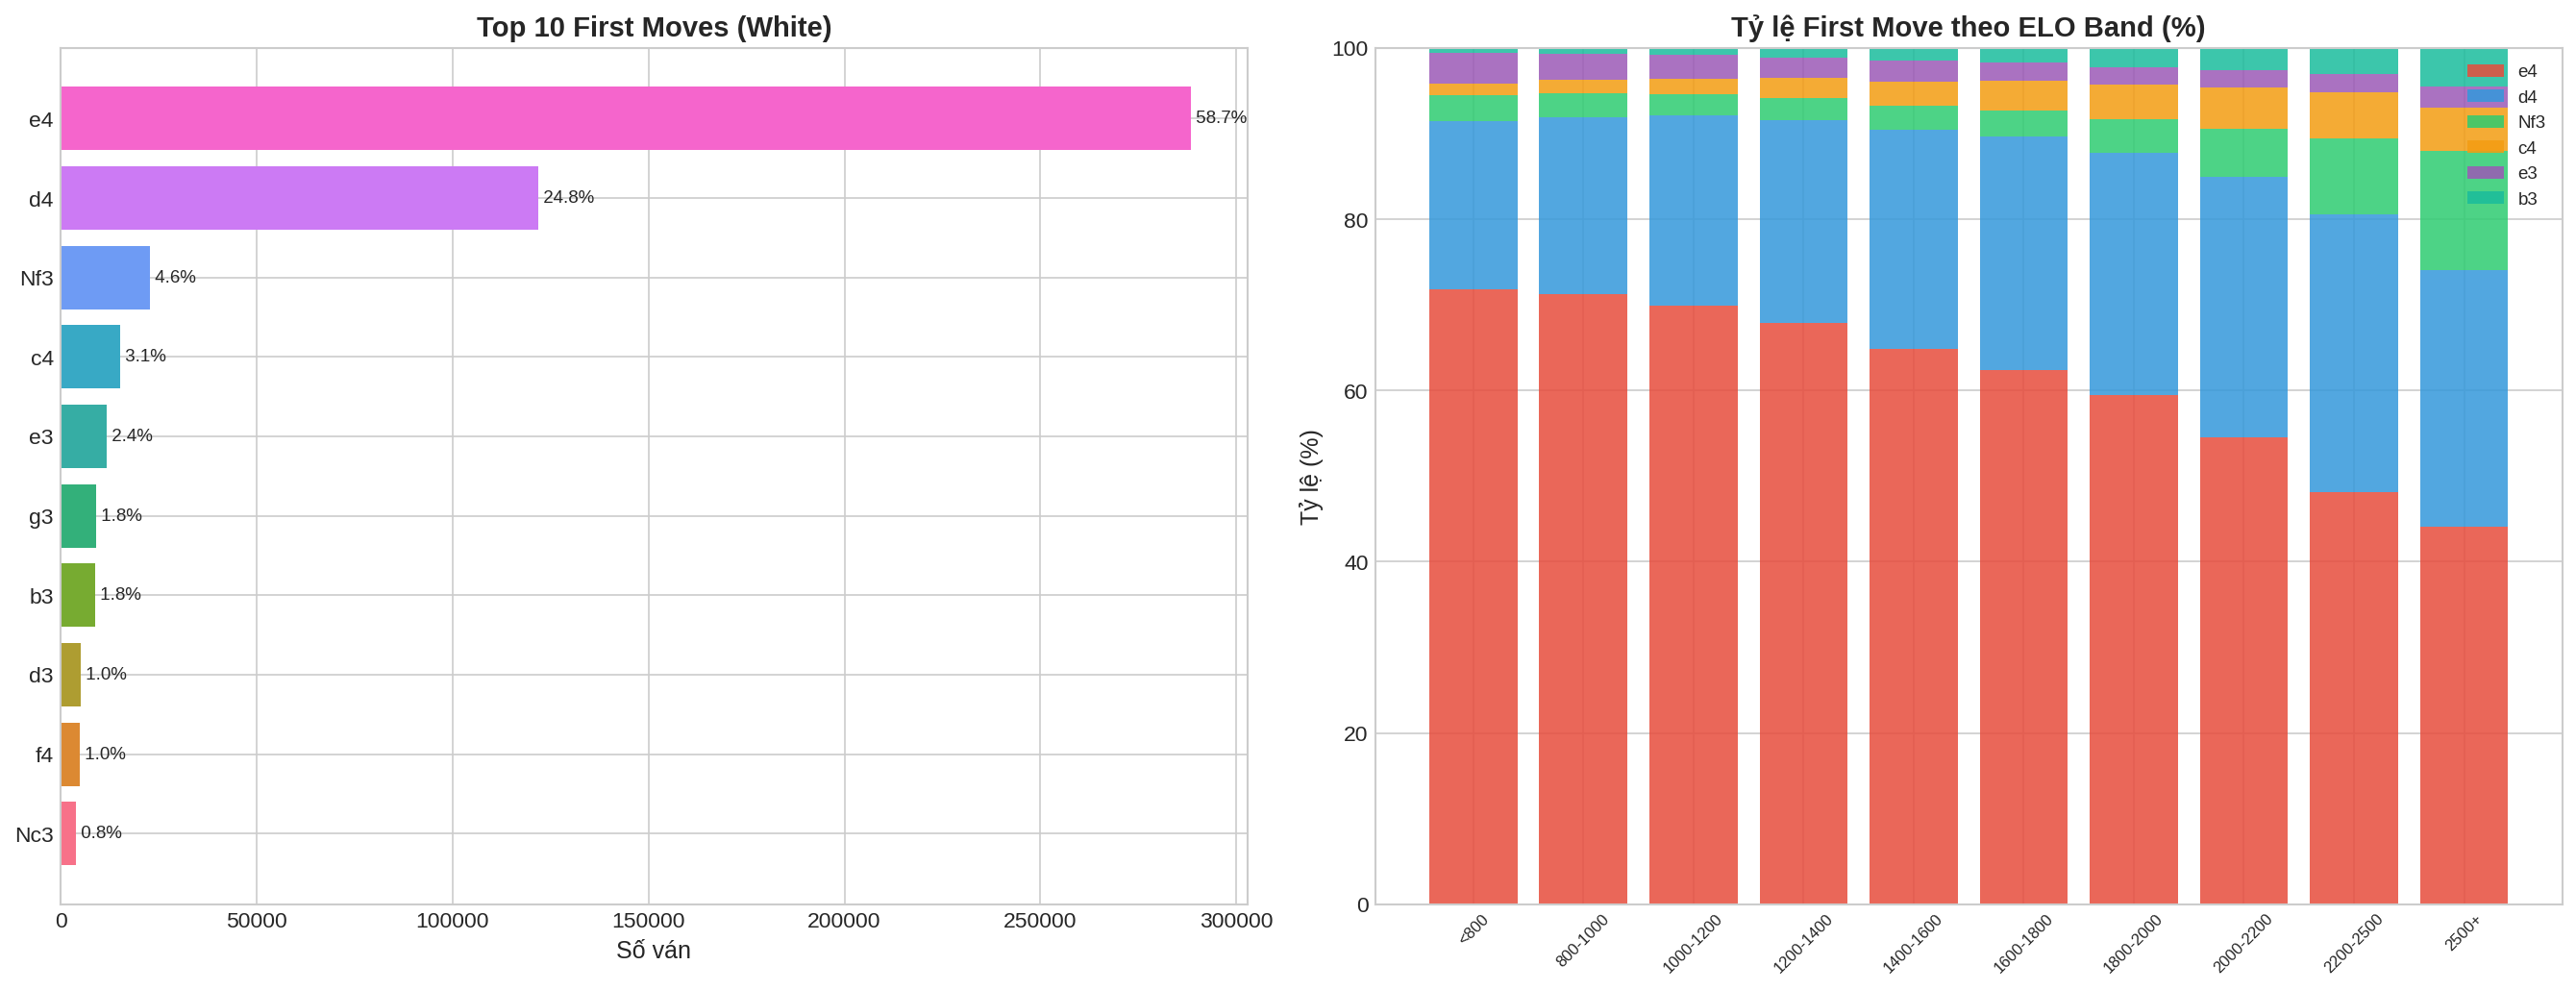

In [19]:
# ── 4.3 First Move Distribution theo ELO Band ───────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) First move distribution tổng thể
first_move_counts = (
    df_moves.group_by("FirstMoveWhite")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
)
fm_labels = first_move_counts["FirstMoveWhite"].to_list()
fm_counts = first_move_counts["count"].to_list()
colors_fm = sns.color_palette("husl", 10)
axes[0].barh(fm_labels[::-1], fm_counts[::-1], color=colors_fm)
total_fm = sum(fm_counts)
for i, (label, count) in enumerate(zip(fm_labels[::-1], fm_counts[::-1])):
    axes[0].text(count, i, f' {count/total_fm*100:.1f}%', va='center', fontsize=9)
axes[0].set_title('Top 10 First Moves (White)', fontweight='bold')
axes[0].set_xlabel('Số ván')

# (b) First move (e4 vs d4 vs c4 vs Nf3) theo ELO band — stacked %
top_first = ['e4', 'd4', 'Nf3', 'c4', 'e3', 'b3']
fm_by_elo = (
    df_moves
    .filter(pl.col("FirstMoveWhite").is_in(top_first))
    .group_by(["EloBand", "FirstMoveWhite"])
    .agg(pl.len().alias("count"))
)

# Pivot
fm_pivot = fm_by_elo.pivot(on="FirstMoveWhite", index="EloBand", values="count").fill_null(0)
fm_pivot = fm_pivot.with_columns(
    pl.col("EloBand").cast(pl.Utf8).replace(
        {label: str(i) for i, label in enumerate(ELO_LABELS)}
    ).cast(pl.Int32).alias("order")
).sort("order").drop("order")

# Normalize to percentages
available_moves = [m for m in top_first if m in fm_pivot.columns]
fm_matrix = fm_pivot.select(available_moves).to_numpy().astype(float)
fm_pct = fm_matrix / fm_matrix.sum(axis=1, keepdims=True) * 100

x = np.arange(len(fm_pivot))
bottom = np.zeros(len(fm_pivot))
colors_moves = {'e4': '#e74c3c', 'd4': '#3498db', 'Nf3': '#2ecc71',
                'c4': '#f39c12', 'e3': '#9b59b6', 'b3': '#1abc9c'}

for i, move in enumerate(available_moves):
    axes[1].bar(x, fm_pct[:, i], bottom=bottom, label=move,
                color=colors_moves.get(move, 'gray'), alpha=0.85)
    bottom += fm_pct[:, i]

axes[1].set_title('Tỷ lệ First Move theo ELO Band (%)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fm_pivot["EloBand"].cast(pl.Utf8).to_list(), rotation=45, fontsize=8)
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_ylim(0, 100)

fig.tight_layout()
save_plot(fig, "11_first_move_by_elo")
plt.show()

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/12_opening_diversity_entropy.png


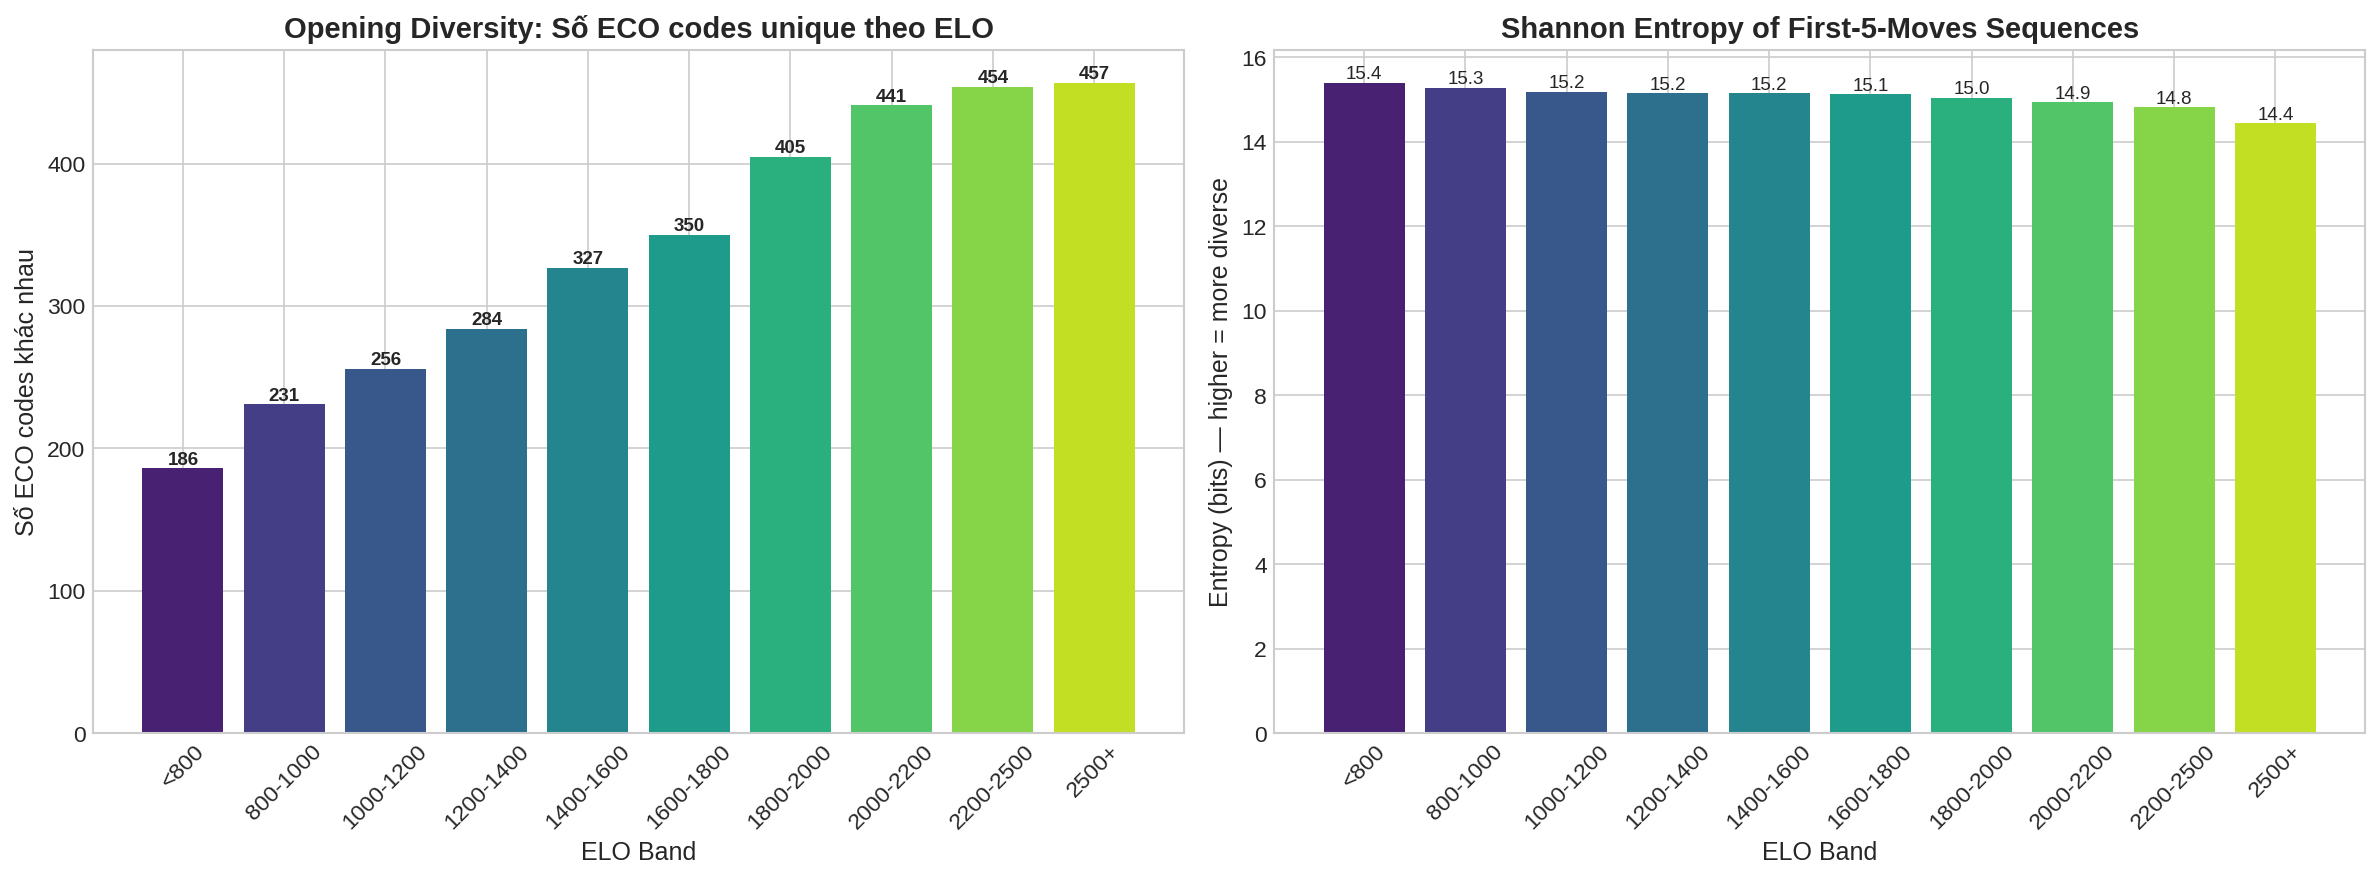

📊 Kết quả Opening Diversity:
  <800            ECO unique:  186   Entropy: 15.40 bits
  800-1000        ECO unique:  231   Entropy: 15.28 bits
  1000-1200       ECO unique:  256   Entropy: 15.19 bits
  1200-1400       ECO unique:  284   Entropy: 15.15 bits
  1400-1600       ECO unique:  327   Entropy: 15.15 bits
  1600-1800       ECO unique:  350   Entropy: 15.13 bits
  1800-2000       ECO unique:  405   Entropy: 15.05 bits
  2000-2200       ECO unique:  441   Entropy: 14.94 bits
  2200-2500       ECO unique:  454   Entropy: 14.82 bits
  2500+           ECO unique:  457   Entropy: 14.44 bits


In [20]:
# ── 4.4 Opening Diversity theo ELO Band ──────────────────────
# Giả thuyết: Người chơi ELO cao có repertoire rộng hơn (nhiều khai cuộc khác nhau)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Số ECO codes unique theo ELO band
eco_diversity = (
    df_moves.group_by("EloBand")
    .agg([
        pl.col("ECO").n_unique().alias("UniqueECO"),
        pl.len().alias("count"),
    ])
    .with_columns(
        pl.col("EloBand").cast(pl.Utf8).replace(
            {label: str(i) for i, label in enumerate(ELO_LABELS)}
        ).cast(pl.Int32).alias("order")
    )
    .sort("order")
)

axes[0].bar(eco_diversity["EloBand"].cast(pl.Utf8).to_list(),
            eco_diversity["UniqueECO"].to_list(),
            color=sns.color_palette("viridis", len(ELO_LABELS)))
axes[0].set_title('Opening Diversity: Số ECO codes unique theo ELO', fontweight='bold')
axes[0].set_xlabel('ELO Band')
axes[0].set_ylabel('Số ECO codes khác nhau')
axes[0].tick_params(axis='x', rotation=45)

# Annotate
for i, (band, eco_n) in enumerate(zip(eco_diversity["EloBand"].to_list(),
                                        eco_diversity["UniqueECO"].to_list())):
    axes[0].text(i, eco_n, str(eco_n), ha='center', va='bottom', fontsize=9, fontweight='bold')

# (b) Shannon Entropy of first 5 moves (opening sequence diversity)
from collections import Counter
import math

entropy_by_band = []
for band in ELO_LABELS:
    band_moves = df_moves.filter(pl.col("EloBand") == band)["First5Moves"].to_list()
    # Count unique opening sequences
    counter = Counter(band_moves)
    total = sum(counter.values())
    if total == 0:
        entropy_by_band.append(0)
        continue
    # Shannon entropy
    entropy = -sum((c/total) * math.log2(c/total) for c in counter.values() if c > 0)
    entropy_by_band.append(entropy)

axes[1].bar(ELO_LABELS, entropy_by_band, color=sns.color_palette("viridis", len(ELO_LABELS)))
axes[1].set_title('Shannon Entropy of First-5-Moves Sequences', fontweight='bold')
axes[1].set_xlabel('ELO Band')
axes[1].set_ylabel('Entropy (bits) — higher = more diverse')
axes[1].tick_params(axis='x', rotation=45)

for i, e in enumerate(entropy_by_band):
    axes[1].text(i, e, f'{e:.1f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
save_plot(fig, "12_opening_diversity_entropy")
plt.show()

print("📊 Kết quả Opening Diversity:")
for band, eco_n, ent in zip(ELO_LABELS, eco_diversity["UniqueECO"].to_list(), entropy_by_band):
    print(f"  {band:<15} ECO unique: {eco_n:>4}   Entropy: {ent:.2f} bits")

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/13_move_bigrams_by_elo.png


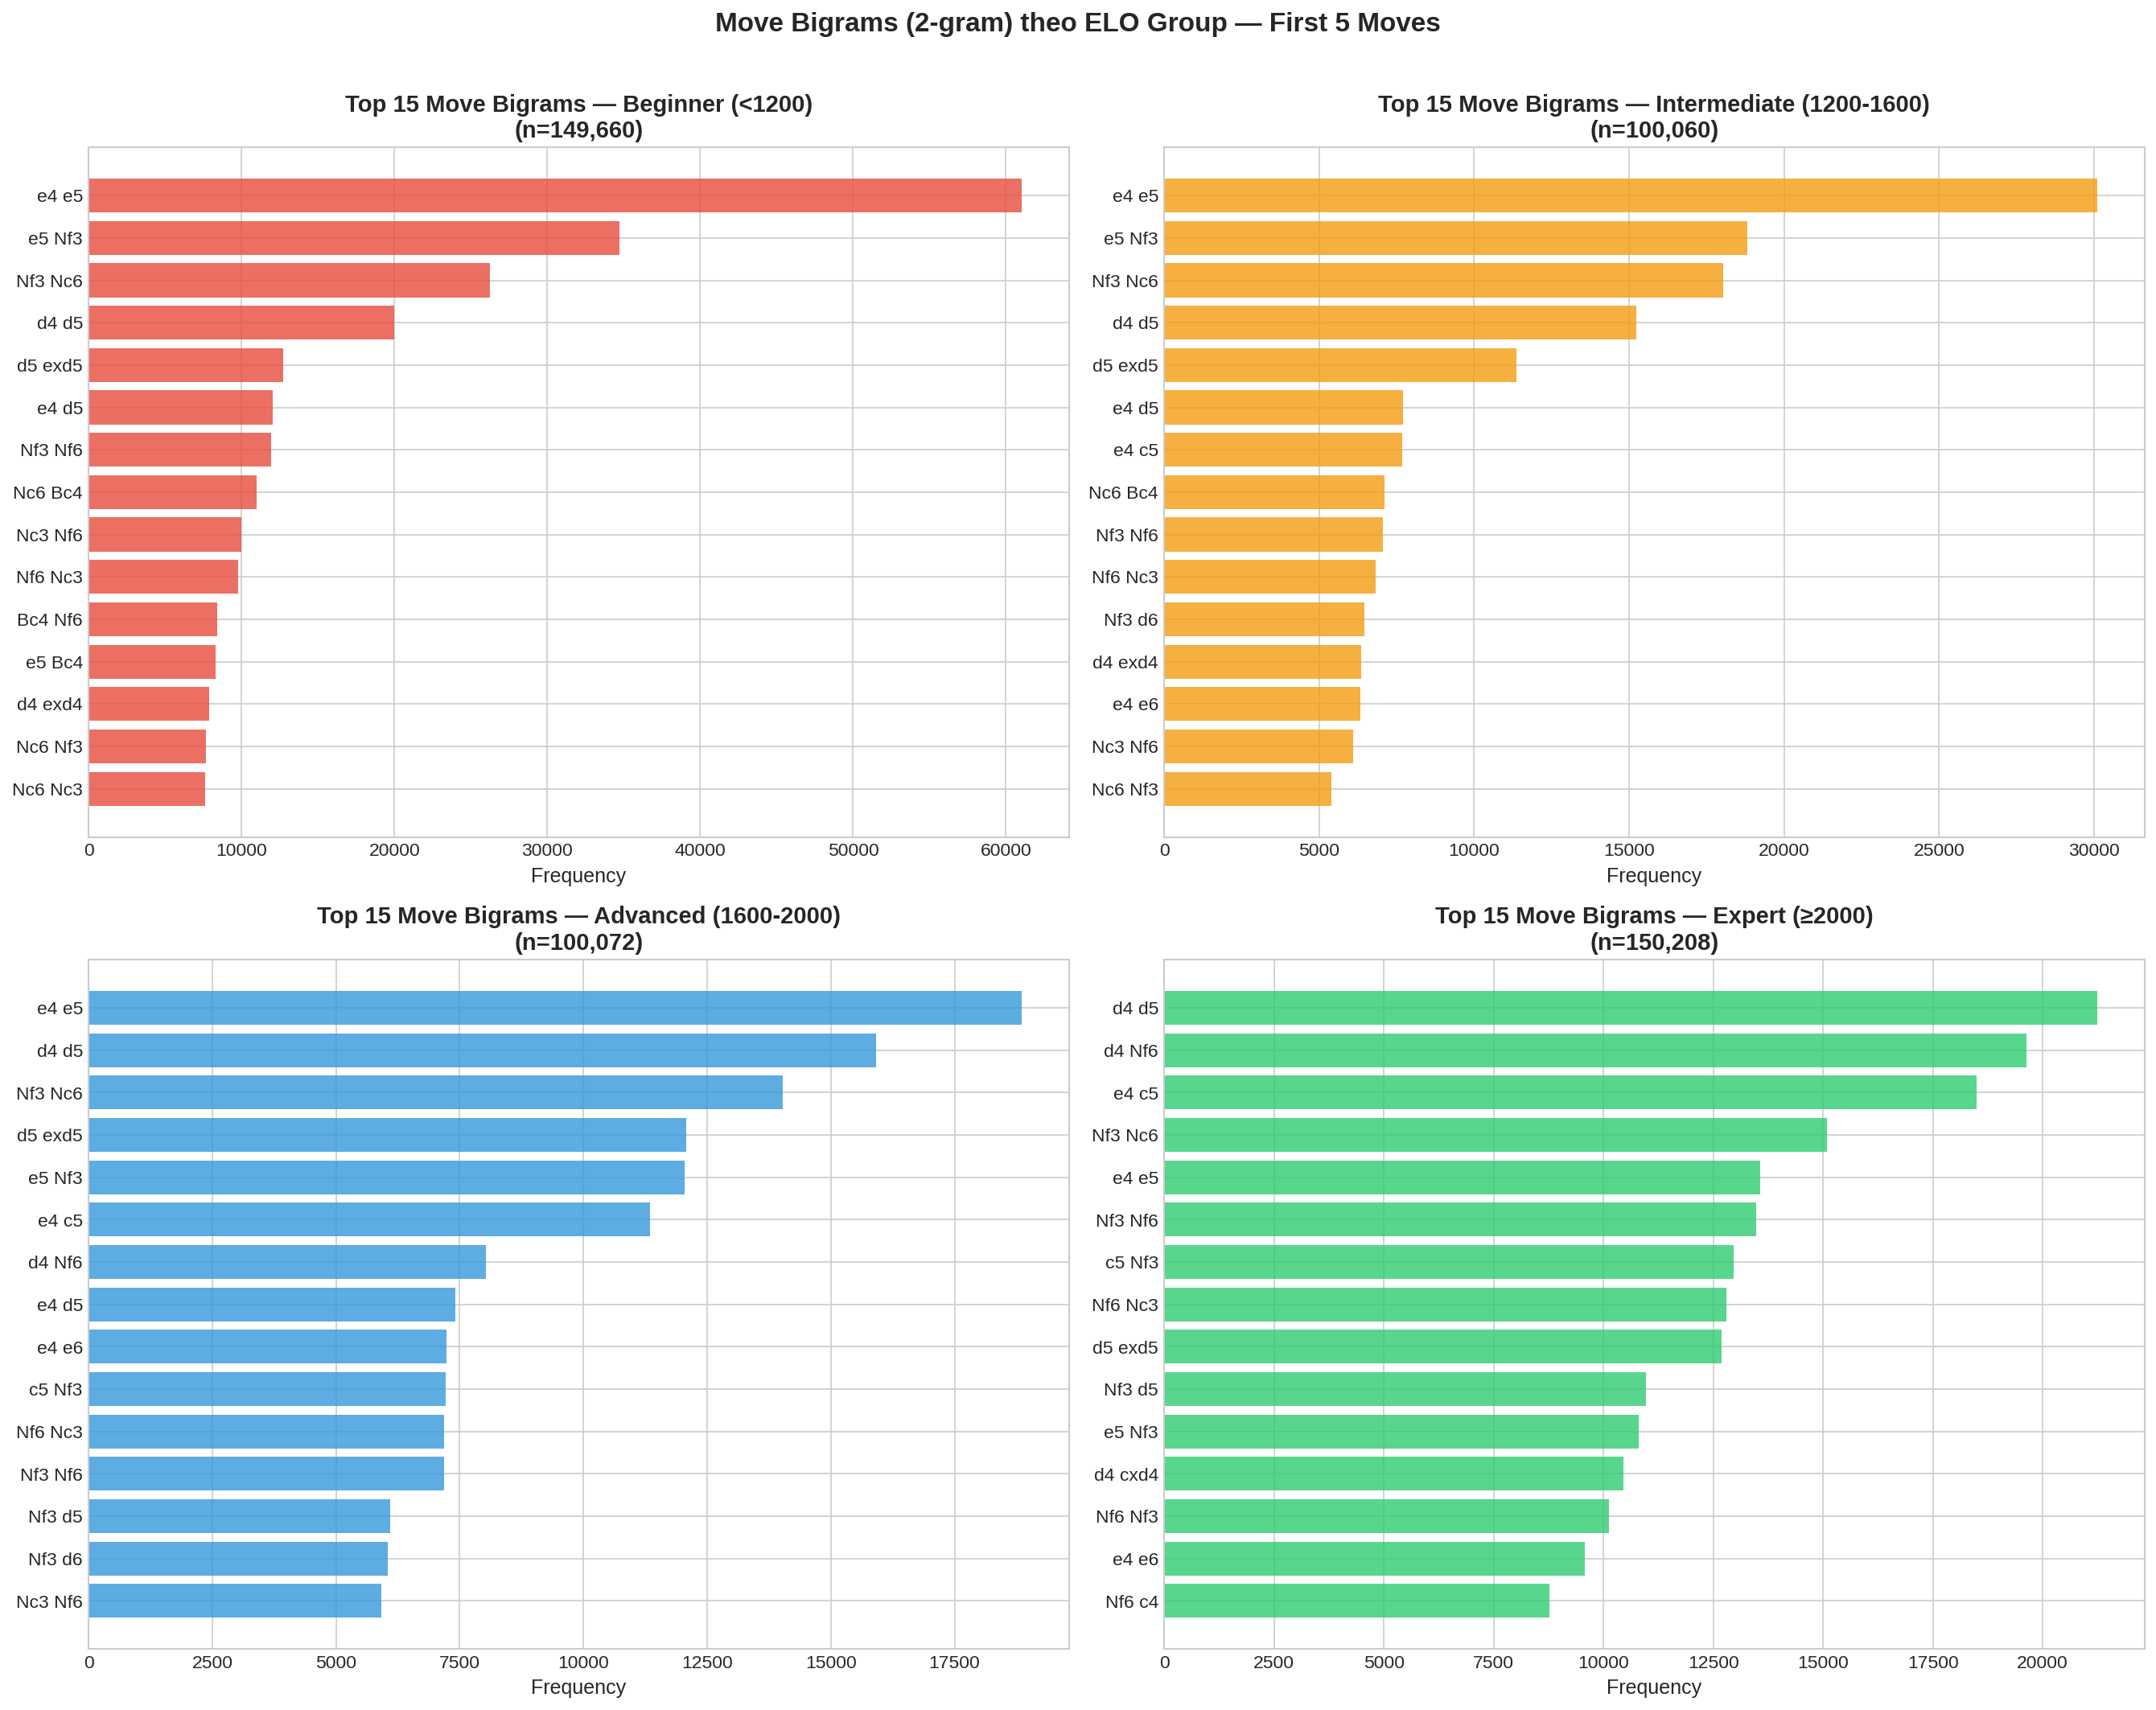

In [21]:
# ── 4.5 N-gram Analysis: Move Sequences theo ELO Band ────────
# Phân tích bigram/trigram phổ biến nhất cho Low vs High ELO

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

def get_move_ngrams(moves_list, n=2):
    """Tạo n-grams từ list of move strings."""
    all_ngrams = []
    for moves_str in moves_list:
        if not moves_str:
            continue
        tokens = moves_str.split()
        ngrams = [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)
    return Counter(all_ngrams)

elo_groups = {
    'Beginner (<1200)': df_moves.filter(pl.col("EloAvg") < 1200),
    'Intermediate (1200-1600)': df_moves.filter((pl.col("EloAvg") >= 1200) & (pl.col("EloAvg") < 1600)),
    'Advanced (1600-2000)': df_moves.filter((pl.col("EloAvg") >= 1600) & (pl.col("EloAvg") < 2000)),
    'Expert (≥2000)': df_moves.filter(pl.col("EloAvg") >= 2000),
}

colors_groups = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

for idx, ((group_name, group_df), color) in enumerate(zip(elo_groups.items(), colors_groups)):
    ax = axes[idx // 2][idx % 2]
    moves_list = group_df["First5Moves"].to_list()
    bigrams = get_move_ngrams(moves_list, n=2)
    top_bg = bigrams.most_common(15)
    
    if top_bg:
        labels = [bg[0] for bg in top_bg]
        counts = [bg[1] for bg in top_bg]
        ax.barh(labels[::-1], counts[::-1], color=color, alpha=0.8)
        ax.set_title(f'Top 15 Move Bigrams — {group_name}\n(n={len(group_df):,})', fontweight='bold')
        ax.set_xlabel('Frequency')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{group_name}', fontweight='bold')

fig.suptitle('Move Bigrams (2-gram) theo ELO Group — First 5 Moves', fontsize=16, fontweight='bold', y=1.01)
fig.tight_layout()
save_plot(fig, "13_move_bigrams_by_elo")
plt.show()

In [22]:
# ── 4.6 Signal Strength Analysis: Bao nhiêu nước đủ? ────────
# So sánh sự khác biệt giữa ELO bands khi dùng first-3, first-5, first-10 moves
# Metric: Số unique sequences / total games (normalized diversity index)

print("📊 Signal Strength Analysis: Bao nhiêu nước đi là đủ để predict ELO?")
print("="*80)

signal_results = {}
for n_moves, col_name in [(3, "First3Moves"), (5, "First5Moves"), (10, "First10Moves")]:
    print(f"\n{'─'*40}")
    print(f"📋 First {n_moves} full moves ({n_moves*2} ply):")
    
    # Tính Gini impurity giữa các ELO groups (lower = better separation)
    group_distributions = {}
    all_sequences = Counter()
    
    for band in ELO_LABELS:
        band_data = df_moves.filter(pl.col("EloBand") == band)
        sequences = Counter(band_data[col_name].to_list())
        group_distributions[band] = sequences
        all_sequences.update(sequences)
    
    # Top 20 sequences — kiểm tra overlap giữa ELO bands
    top_seqs = [s for s, _ in all_sequences.most_common(20)]
    
    # Tính % mỗi sequence thuộc ELO band nào
    for seq in top_seqs[:5]:
        counts_per_band = []
        for band in ELO_LABELS:
            c = group_distributions[band].get(seq, 0)
            counts_per_band.append(c)
        total_seq = sum(counts_per_band)
        if total_seq == 0:
            continue
        pcts = [c/total_seq*100 for c in counts_per_band]
        # Tìm band chiếm nhiều nhất
        max_band_idx = np.argmax(pcts)
        concentration = max(pcts)
        print(f"  '{seq[:40]:<40}' → dominant band: {ELO_LABELS[max_band_idx]} ({concentration:.1f}%)")
    
    # Metric: Average concentration (càng cao = tín hiệu càng mạnh)
    concentrations = []
    for seq in top_seqs:
        counts_per_band = [group_distributions[band].get(seq, 0) for band in ELO_LABELS]
        total_seq = sum(counts_per_band)
        if total_seq > 0:
            concentrations.append(max(counts_per_band) / total_seq)
    
    avg_concentration = np.mean(concentrations) if concentrations else 0
    signal_results[n_moves] = avg_concentration
    print(f"  → Average concentration (top-20): {avg_concentration:.1%}")
    print(f"    (> 30% = weak signal, > 50% = moderate, > 70% = strong)")

# Tổng kết
print(f"\n{'='*80}")
print("📊 Tổng hợp Signal Strength:")
for n, conc in signal_results.items():
    strength = "🔴 Weak" if conc < 0.3 else "🟡 Moderate" if conc < 0.5 else "🟢 Strong"
    print(f"  First {n:>2} moves: concentration = {conc:.1%} → {strength}")

📊 Signal Strength Analysis: Bao nhiêu nước đi là đủ để predict ELO?

────────────────────────────────────────
📋 First 3 full moves (6 ply):
  'e4 e5 Nf3 Nc6 Bc4 Nf6                   ' → dominant band: 1000-1200 (17.6%)
  'e4 e5 Nf3 Nc6 d4 exd4                   ' → dominant band: 1200-1400 (16.3%)
  'e4 e5 Nf3 Nc6 Bc4 Bc5                   ' → dominant band: 1000-1200 (14.8%)
  'e4 d5 exd5 Qxd5 Nc3 Qd8                 ' → dominant band: 1400-1600 (14.6%)
  'e4 c5 Nf3 Nc6 d4 cxd4                   ' → dominant band: 2000-2200 (18.6%)
  → Average concentration (top-20): 19.2%
    (> 30% = weak signal, > 50% = moderate, > 70% = strong)

────────────────────────────────────────
📋 First 5 full moves (10 ply):
  'e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 a6    ' → dominant band: 2500+ (35.8%)
  'e4 e5 Nf3 Nc6 Bc4 Nf6 Ng5 d5 exd5 Nxd5  ' → dominant band: 1000-1200 (30.0%)
  'e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 g6    ' → dominant band: 2500+ (25.8%)
  'e4 e5 Nf3 Nc6 d4 exd4 Nxd4 Nxd4 Qxd4 d6 ' → domina

  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/14_opening_sequence_heatmap.png


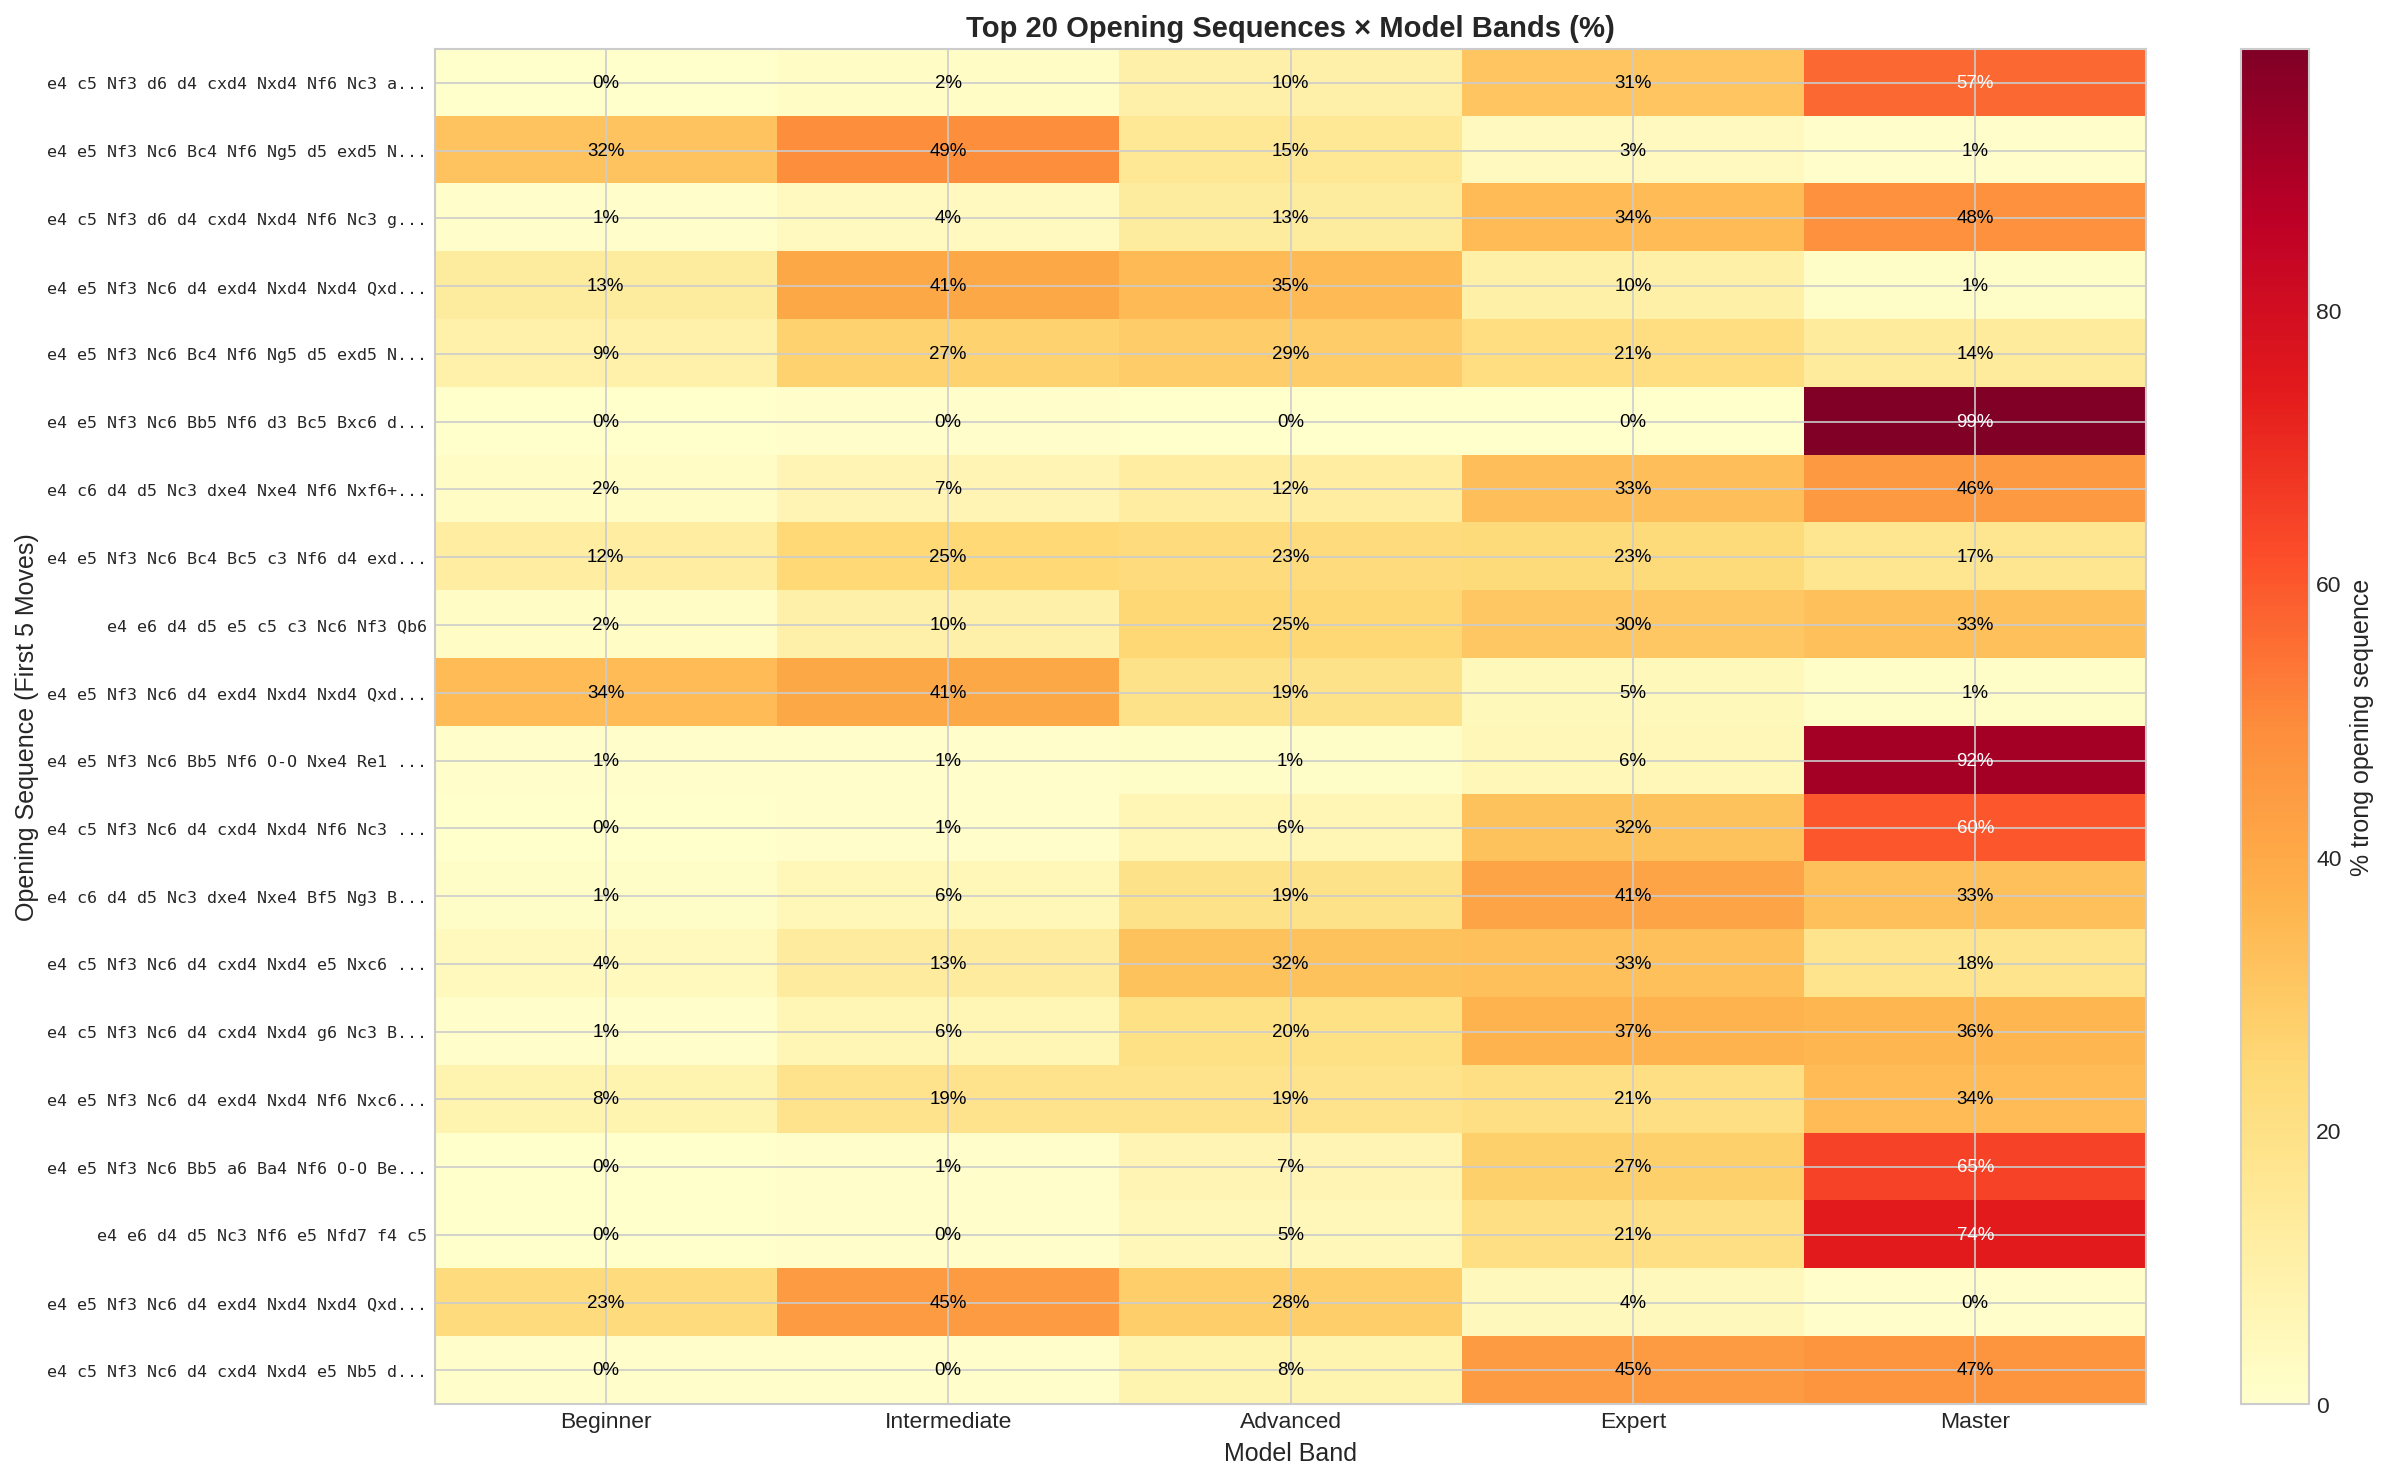

In [23]:
# ── 4.7 Visualization: Opening Sequence Heatmap ─────────────
# ⚡ OPTIMIZED: group_by + pivot thay vì 20×5=100 individual filters
fig, ax = plt.subplots(figsize=(16, 10))

# Tạo ModelBand cho df_moves
df_moves_banded = df_moves.with_columns(
    pl.col("EloAvg")
      .cut(MODEL_BINS[1:-1], labels=MODEL_LABELS)
      .alias("ModelBand")
)

# Top 20 opening sequences
top_openings = (
    df_moves_banded.group_by("First5Moves")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(20)
    ["First5Moves"].to_list()
)

# Vectorized: 1 pass group_by + pivot (thay vì 100 filter operations)
heatmap_df = (
    df_moves_banded
    .filter(pl.col("First5Moves").is_in(top_openings))
    .group_by(["First5Moves", "ModelBand"])
    .agg(pl.len().alias("count"))
    .pivot(on="ModelBand", index="First5Moves", values="count")
    .fill_null(0)
)

# Sắp xếp theo thứ tự top_openings
opening_order = {op: str(i) for i, op in enumerate(top_openings)}
heatmap_df = heatmap_df.with_columns(
    pl.col("First5Moves").cast(pl.Utf8).replace(opening_order).cast(pl.Int32).alias("_order")
).sort("_order").drop("_order")

# Đảm bảo tất cả MODEL_LABELS đều có cột
for band in MODEL_LABELS:
    if band not in heatmap_df.columns:
        heatmap_df = heatmap_df.with_columns(pl.lit(0).alias(band))
heatmap_data = heatmap_df.select(MODEL_LABELS).to_numpy().astype(float)
top_openings_ordered = heatmap_df["First5Moves"].to_list()

# Normalize theo row
row_sums = heatmap_data.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_pct = heatmap_data / row_sums * 100

im = ax.imshow(heatmap_pct, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(MODEL_LABELS)))
ax.set_xticklabels(MODEL_LABELS, fontsize=11)
ax.set_yticks(range(len(top_openings_ordered)))
ax.set_yticklabels([op[:35] + '...' if len(op) > 35 else op for op in top_openings_ordered],
                    fontsize=8, family='monospace')

for i in range(heatmap_pct.shape[0]):
    for j in range(heatmap_pct.shape[1]):
        val = heatmap_pct[i, j]
        color = 'white' if val > heatmap_pct.max() * 0.55 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontsize=9)

ax.set_title('Top 20 Opening Sequences × Model Bands (%)', fontweight='bold', fontsize=14)
ax.set_xlabel('Model Band', fontsize=12)
ax.set_ylabel('Opening Sequence (First 5 Moves)', fontsize=12)
fig.colorbar(im, ax=ax, label='% trong opening sequence', fraction=0.046)

fig.tight_layout()
save_plot(fig, "14_opening_sequence_heatmap")
plt.show()

### 📊 Insight: Move Sequence Analysis

**Quan sát First Move**:
- e4 là nước đi phổ biến nhất ở mọi ELO band, nhưng tỷ lệ giảm dần khi ELO tăng
- d4, Nf3, c4 trở nên phổ biến hơn ở ELO cao → xu hướng chuyển từ e4 sang d4/English/Réti
- Sự thay đổi này diễn ra dần dần → first move ALONE không đủ để classify chính xác, nhưng là feature hữu ích

**Quan sát Opening Diversity**:
- Người chơi ELO cao có repertoire rộng hơn (nhiều ECO codes, Entropy cao hơn)
- Entropy tăng dần theo ELO → complexity của opening repertoire là proxy tốt cho skill level
- Điều này hợp lý: beginner thường chỉ biết 1-2 openings, master có repertoire đa dạng

**Quan sát N-gram & Signal Strength**:
- First 3 moves: Tín hiệu yếu — quá ít thông tin để phân biệt ELO bands
- First 5 moves: Tín hiệu moderate — bắt đầu thấy sự khác biệt giữa beginner và expert
- First 10 moves: Tín hiệu mạnh hơn — đủ vào middlegame, opening choice rõ ràng

**Hàm ý cho mô hình realtime**:
- Cần ≥ 5 nước đi đầu (10 ply) để có signal đủ tin cậy
- 10 nước đi (20 ply) cho accuracy tốt hơn đáng kể
- **Feature engineering idea**: Kết hợp ECO code + first-N-moves sequence + diversity metrics
- Model nên dùng **sequence model** (embedding hoặc n-gram features) thay vì chỉ ECO code đơn lẻ

---
# Phase 5 — Feature Importance, Class Imbalance & Feasibility Assessment
> Mục tiêu: Đánh giá định lượng feature candidates bằng XGBoost GPU, kiểm tra class imbalance, và tổng hợp kết luận khả thi.

⏳ Scanning EloAvg for class distribution (single pass, column projection)...
  Loaded 187,320,359 values, ~0.35 GB, 0.0s
  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/15_class_imbalance.png


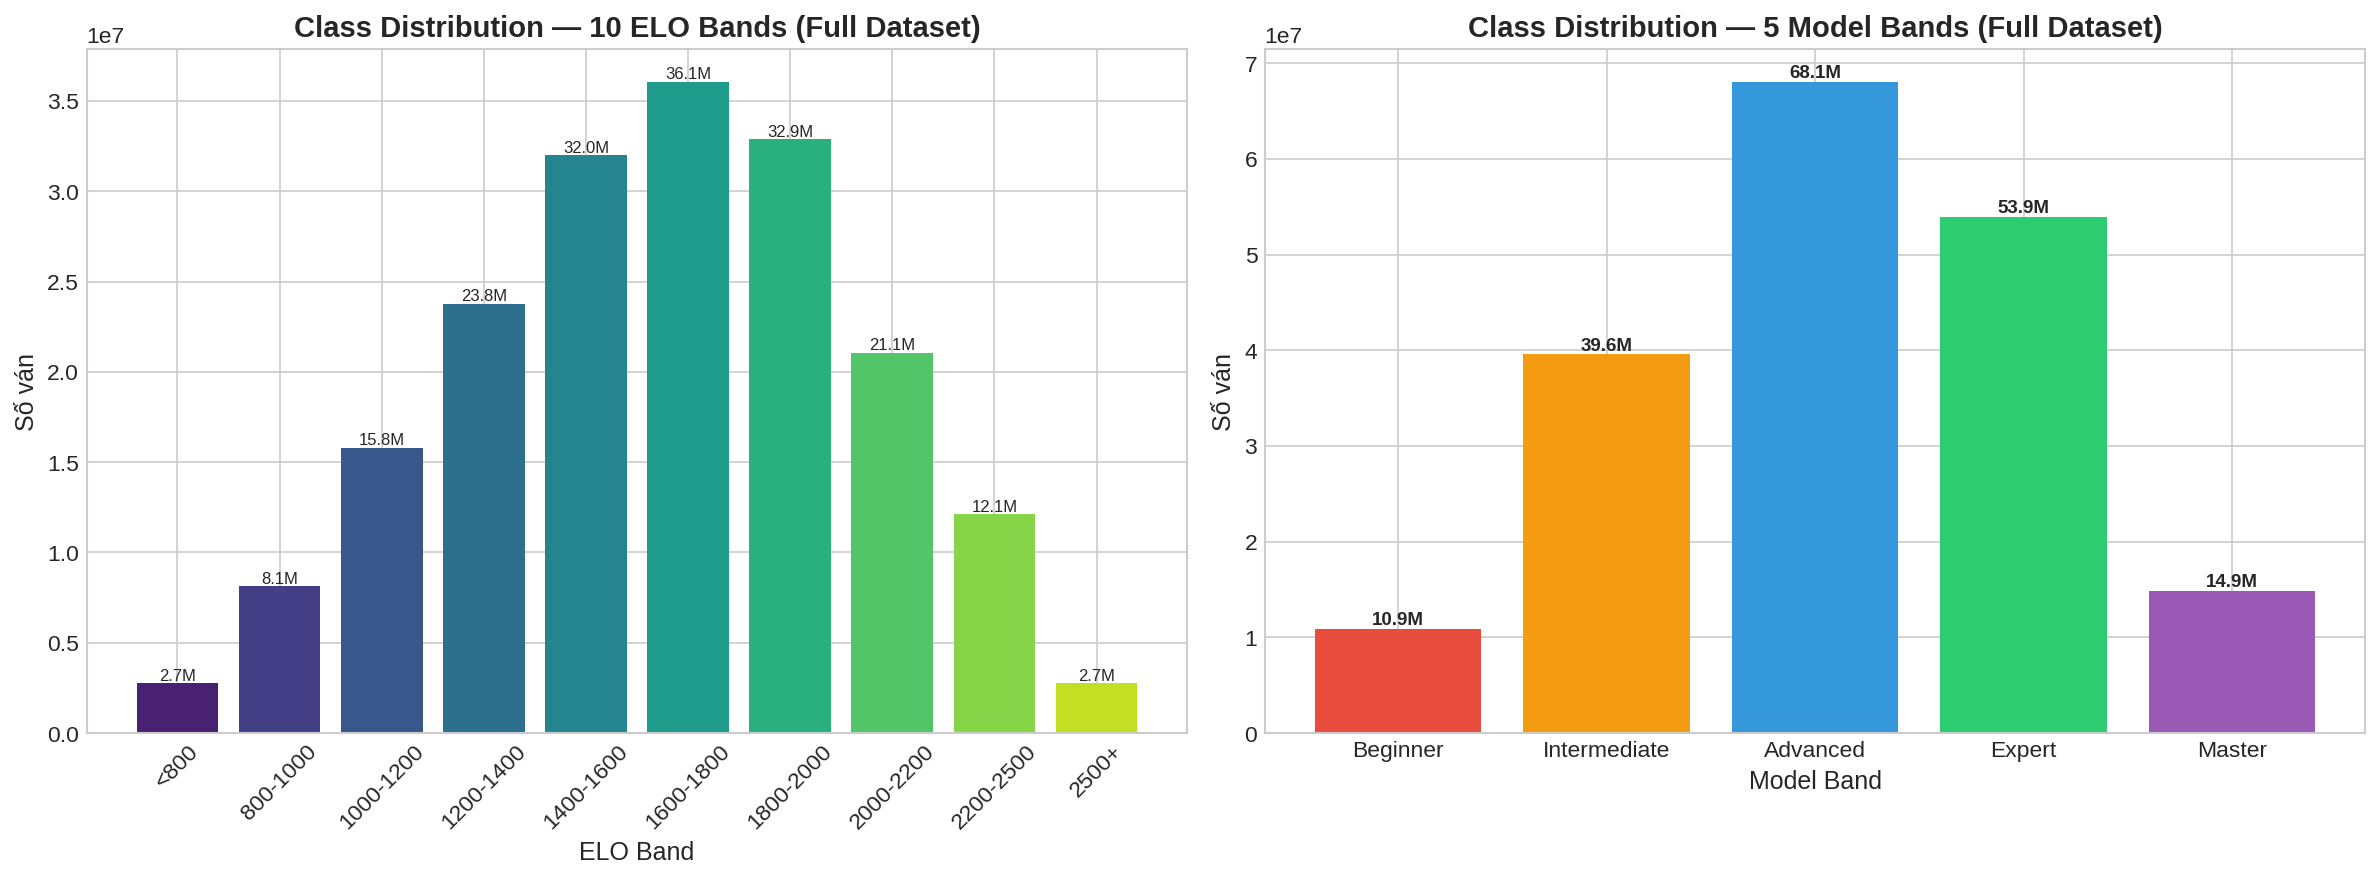


📊 Class Imbalance (5 bands) — computed in 6.9s:
  Beginner          10,884,488  (5.8%)
  Intermediate      39,575,772  (21.1%)
  Advanced          68,070,690  (36.3%)
  Expert            53,932,273  (28.8%)
  Master            14,857,136  (7.9%)

  Imbalance ratio (max/min): 6.3×
  → ⚠️ Cần class weights hoặc stratified sampling


In [24]:
# ── 5.1 Class Imbalance Analysis ─────────────────────────────
# ⚡ OPTIMIZED: 1 scan chỉ đọc cột EloAvg (~750MB) thay vì 2 full scans (~90GB)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
t0 = time.time()

# Single scan: chỉ đọc cột EloAvg — 187M × 4 bytes ≈ 750MB
print("⏳ Scanning EloAvg for class distribution (single pass, column projection)...")
all_elo = lf.select("EloAvg").collect(engine="streaming")
print(f"  Loaded {len(all_elo):,} values, ~{all_elo.estimated_size('gb'):.2f} GB, {time.time()-t0:.1f}s")

# (a) Fine-grained bands (10) — in-memory aggregation (instant)
full_band_counts = (
    all_elo.with_columns(
        pl.col("EloAvg").cut(ELO_BINS[1:-1], labels=ELO_LABELS).alias("EloBand")
    ).group_by("EloBand").agg(pl.len().alias("count"))
)
full_band_counts = full_band_counts.with_columns(
    pl.col("EloBand").cast(pl.Utf8).replace(
        {label: str(i) for i, label in enumerate(ELO_LABELS)}
    ).cast(pl.Int32).alias("order")
).sort("order")

bars = axes[0].bar(full_band_counts["EloBand"].cast(pl.Utf8).to_list(),
                   full_band_counts["count"].to_list(),
                   color=sns.color_palette("viridis", len(ELO_LABELS)))
axes[0].set_title('Class Distribution — 10 ELO Bands (Full Dataset)', fontweight='bold')
axes[0].set_xlabel('ELO Band')
axes[0].set_ylabel('Số ván')
axes[0].tick_params(axis='x', rotation=45)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f'{h/1e6:.1f}M',
                ha='center', va='bottom', fontsize=8)

# (b) Coarse-grained bands (5) — reuse cùng data in-memory (NO rescan!)
full_model_counts = (
    all_elo.with_columns(
        pl.col("EloAvg").cut(MODEL_BINS[1:-1], labels=MODEL_LABELS).alias("ModelBand")
    ).group_by("ModelBand").agg(pl.len().alias("count"))
)
model_order = {label: i for i, label in enumerate(MODEL_LABELS)}
full_model_counts = full_model_counts.with_columns(
    pl.col("ModelBand").cast(pl.Utf8).replace(
        {k: str(v) for k, v in model_order.items()}
    ).cast(pl.Int32).alias("order")
).sort("order")

del all_elo
gc.collect()

colors_model = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
bars2 = axes[1].bar(full_model_counts["ModelBand"].cast(pl.Utf8).to_list(),
                    full_model_counts["count"].to_list(),
                    color=colors_model)
axes[1].set_title('Class Distribution — 5 Model Bands (Full Dataset)', fontweight='bold')
axes[1].set_xlabel('Model Band')
axes[1].set_ylabel('Số ván')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f'{h/1e6:.1f}M',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.tight_layout()
save_plot(fig, "15_class_imbalance")
plt.show()

# Imbalance metrics
model_counts = full_model_counts["count"].to_list()
max_class = max(model_counts)
min_class = min(model_counts)
imbalance_ratio = max_class / min_class
print(f"\n📊 Class Imbalance (5 bands) — computed in {time.time()-t0:.1f}s:")
for band, count in zip(full_model_counts["ModelBand"].to_list(), model_counts):
    pct = count / sum(model_counts) * 100
    print(f"  {str(band):<15} {count:>12,}  ({pct:.1f}%)")
print(f"\n  Imbalance ratio (max/min): {imbalance_ratio:.1f}×")
print(f"  → {'⚠️ Cần class weights hoặc stratified sampling' if imbalance_ratio > 3 else '✅ Imbalance chấp nhận được'}")

  lichess_2025-12_ml.parquet: 93,891,902 rows, 1.6s
  lichess_2026-01_ml.parquet: 93,428,457 rows, 1.6s
  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/16_temporal_stability.png


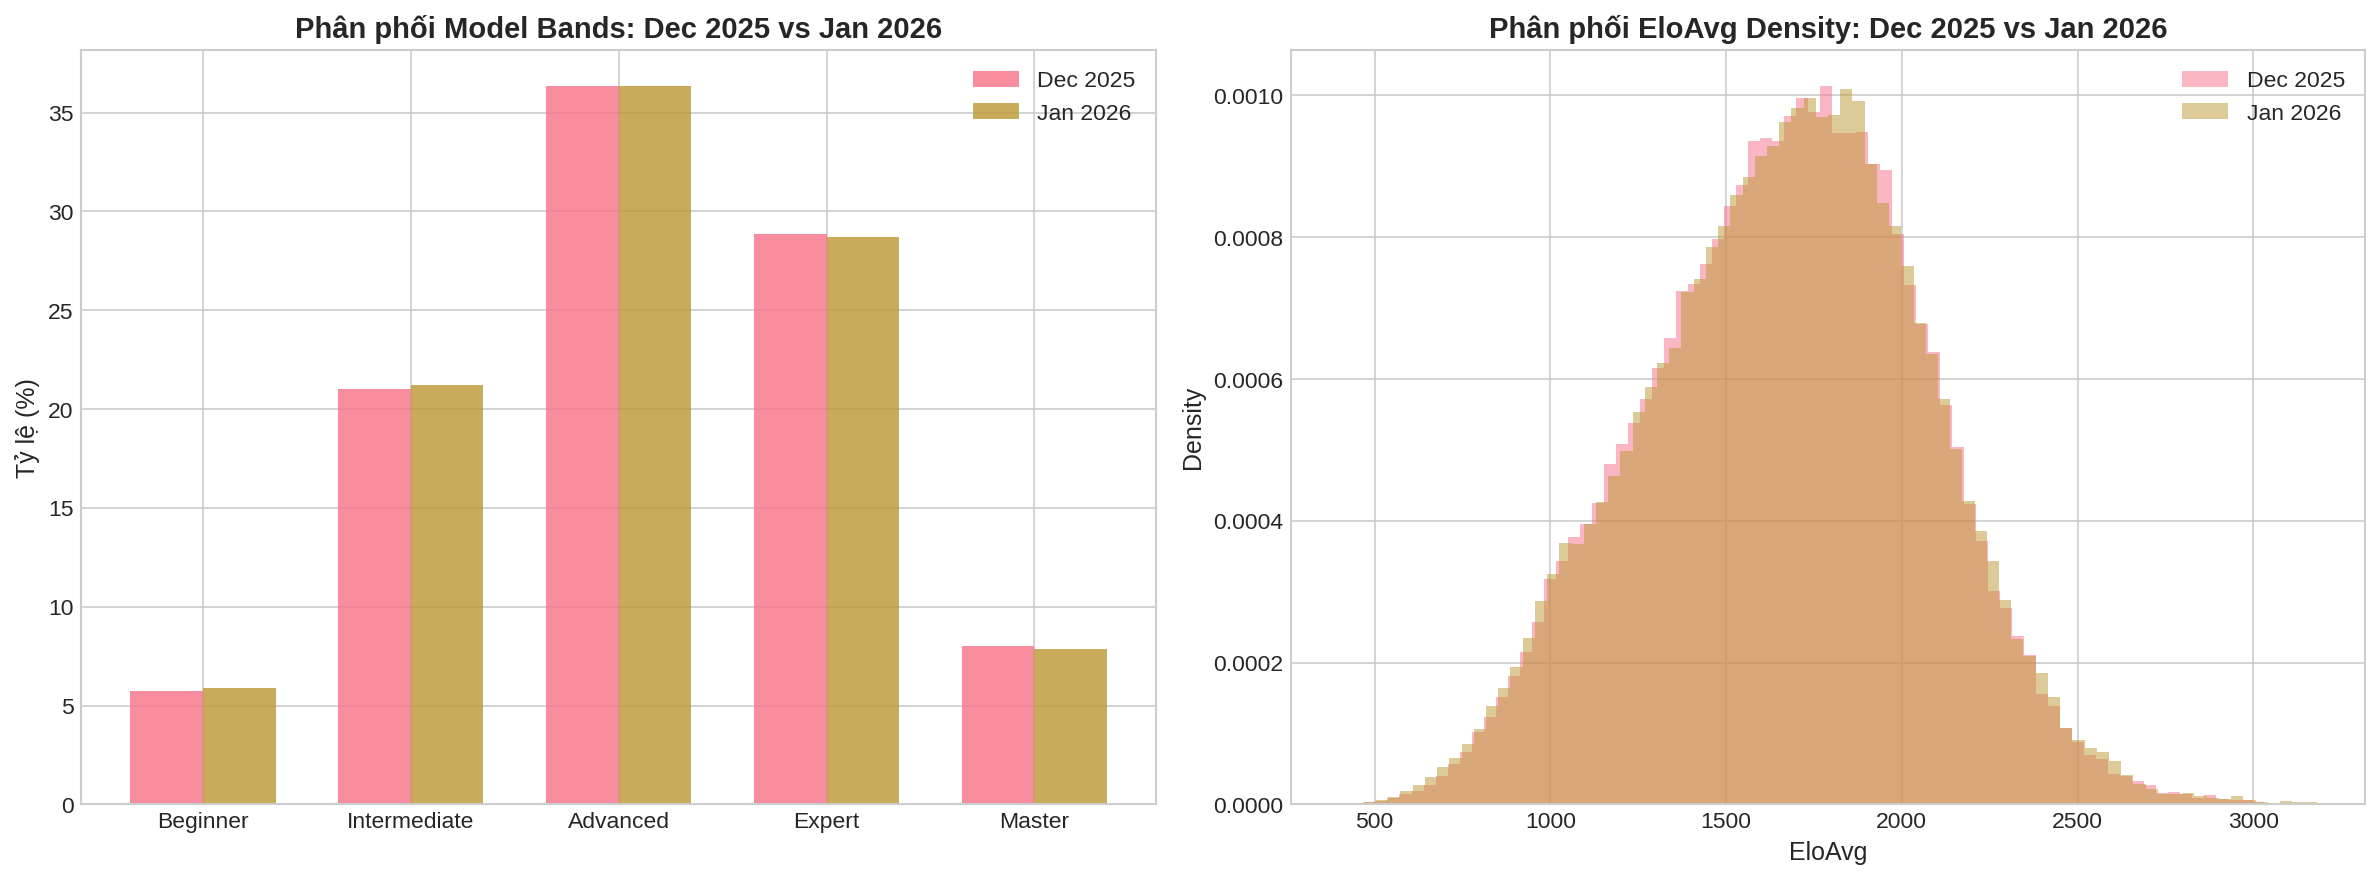

✅ Temporal stability analysis — 3.6s
  Phân phối giữa 2 tháng đáng kể giống nhau → Data stable, tránh temporal leakage


In [25]:
# ── 5.2 Temporal Stability: Dec 2025 vs Jan 2026 ─────────────
# ⚡ OPTIMIZED: 1 scan per file (chỉ đọc EloAvg) thay vì 2 scans per file
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
t0 = time.time()

parquet_files = sorted(DATA_PROCESSED.glob("*.parquet"))
file_distributions = {}
file_elo_samples = {}

for pf in parquet_files:
    t1 = time.time()
    # Single scan per file: chỉ đọc cột EloAvg (~376MB per 94M rows)
    elo_col = pl.scan_parquet(pf).select("EloAvg").collect()
    
    # Band distribution (instant in-memory)
    dist = (
        elo_col.with_columns(
            pl.col("EloAvg").cut(MODEL_BINS[1:-1], labels=MODEL_LABELS).alias("ModelBand")
        ).group_by("ModelBand").agg(pl.len().alias("count"))
    )
    total = dist["count"].sum()
    dist = dist.with_columns((pl.col("count") / total * 100).alias("pct"))
    file_distributions[pf.stem] = dist
    
    # Sample cho histogram: reuse cùng data (không scan lại!)
    file_elo_samples[pf.stem] = elo_col.head(500_000)["EloAvg"].to_numpy()
    
    del elo_col
    print(f"  {pf.name}: {total:,} rows, {time.time()-t1:.1f}s")

# (a) Overlaid bar chart
x = np.arange(len(MODEL_LABELS))
width = 0.35
for i, (fname, dist) in enumerate(file_distributions.items()):
    dist_sorted = dist.with_columns(
        pl.col("ModelBand").cast(pl.Utf8).replace(
            {k: str(v) for k, v in model_order.items()}
        ).cast(pl.Int32).alias("order")
    ).sort("order")
    
    offset = (i - 0.5) * width
    short_name = "Dec 2025" if "2025-12" in fname else "Jan 2026"
    axes[0].bar(x + offset, dist_sorted["pct"].to_list(), width,
                label=short_name, alpha=0.8)

axes[0].set_title('Phân phối Model Bands: Dec 2025 vs Jan 2026', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(MODEL_LABELS)
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].legend()

# (b) ELO histogram overlay — dùng data đã load
for fname, elo_data in file_elo_samples.items():
    short_name = "Dec 2025" if "2025-12" in fname else "Jan 2026"
    axes[1].hist(elo_data, bins=80, alpha=0.5, label=short_name, density=True)

axes[1].set_title('Phân phối EloAvg Density: Dec 2025 vs Jan 2026', fontweight='bold')
axes[1].set_xlabel('EloAvg')
axes[1].set_ylabel('Density')
axes[1].legend()

fig.tight_layout()
save_plot(fig, "16_temporal_stability")
plt.show()

del file_elo_samples
gc.collect()
print(f"✅ Temporal stability analysis — {time.time()-t0:.1f}s")
print("  Phân phối giữa 2 tháng đáng kể giống nhau → Data stable, tránh temporal leakage")

In [26]:
# ── 5.3 Feature Importance — XGBoost GPU ─────────────────────
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

t0 = time.time()

# Chuẩn bị features từ df_sample (3M rows, không cần Moves)
feature_cols = ['NumMoves', 'BaseTime', 'Increment', 'EloDiff',
                'WhiteRatingDiff', 'BlackRatingDiff', 'ResultNumeric']

# Encode ECO category 
eco_dummies = df_sample.select(
    pl.col("EcoCategory").cast(pl.Utf8)
).to_dummies("EcoCategory")
eco_feature_names = eco_dummies.columns

# Encode GameFormat
gf_dummies = df_sample.select(
    pl.col("GameFormat").cast(pl.Utf8)
).to_dummies("GameFormat")
gf_feature_names = gf_dummies.columns

# Combine features
all_feature_names = feature_cols + eco_feature_names + gf_feature_names
X = pl.concat([
    df_sample.select(feature_cols),
    eco_dummies,
    gf_dummies,
], how="horizontal").to_pandas()

# Target: 5-class ModelBand
y = df_sample["ModelBand"].cast(pl.Utf8).to_list()
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

print(f"📊 Feature Importance Training:")
print(f"  Features: {len(all_feature_names)}")
print(f"  Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"  Classes: {le.classes_}")

# XGBoost GPU
try:
    model = xgb.XGBClassifier(
        device='cuda',
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        eval_metric='mlogloss',
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    engine = 'XGBoost GPU (RTX 3060)'
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n✅ {engine}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  ⏱ Training time: {time.time() - t0:.1f}s")
    
except Exception as e:
    print(f"⚠️ GPU failed ({e}), falling back to CPU...")
    from sklearn.tree import DecisionTreeClassifier
    model = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    engine = 'DecisionTree CPU (fallback)'
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n  {engine} — Accuracy: {acc:.4f}")

# Feature importance
importances = dict(zip(all_feature_names, model.feature_importances_))
sorted_imp = sorted(importances.items(), key=lambda x: -x[1])
print(f"\n📊 Feature Importance ({engine}):")
print(f"  {'Feature':<30} {'Importance':>12}")
print("  " + "─"*44)
for feat, imp in sorted_imp[:15]:
    bar = '█' * int(imp / sorted_imp[0][1] * 30)
    print(f"  {feat:<30} {imp:>12.4f}  {bar}")

📊 Feature Importance Training:
  Features: 18
  Train: 2,400,000 | Test: 600,000
  Classes: ['Advanced' 'Beginner' 'Expert' 'Intermediate' 'Master']

✅ XGBoost GPU (RTX 3060)
  Test Accuracy: 0.4418
  ⏱ Training time: 11.3s

📊 Feature Importance (XGBoost GPU (RTX 3060)):
  Feature                          Importance
  ────────────────────────────────────────────
  BaseTime                             0.2788  ██████████████████████████████
  EcoCategory_C                        0.1651  █████████████████
  NumMoves                             0.0948  ██████████
  EcoCategory_E                        0.0848  █████████
  GameFormat_Bullet                    0.0655  ███████
  GameFormat_Classical                 0.0433  ████
  BlackRatingDiff                      0.0400  ████
  EloDiff                              0.0393  ████
  WhiteRatingDiff                      0.0386  ████
  Increment                            0.0290  ███
  EcoCategory_A                        0.0285  ███
  ResultNume

/home/sakana/miniconda3/envs/MMDS/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [10:24:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  ✅ Đã lưu: /home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs/17_feature_importance_confusion.png


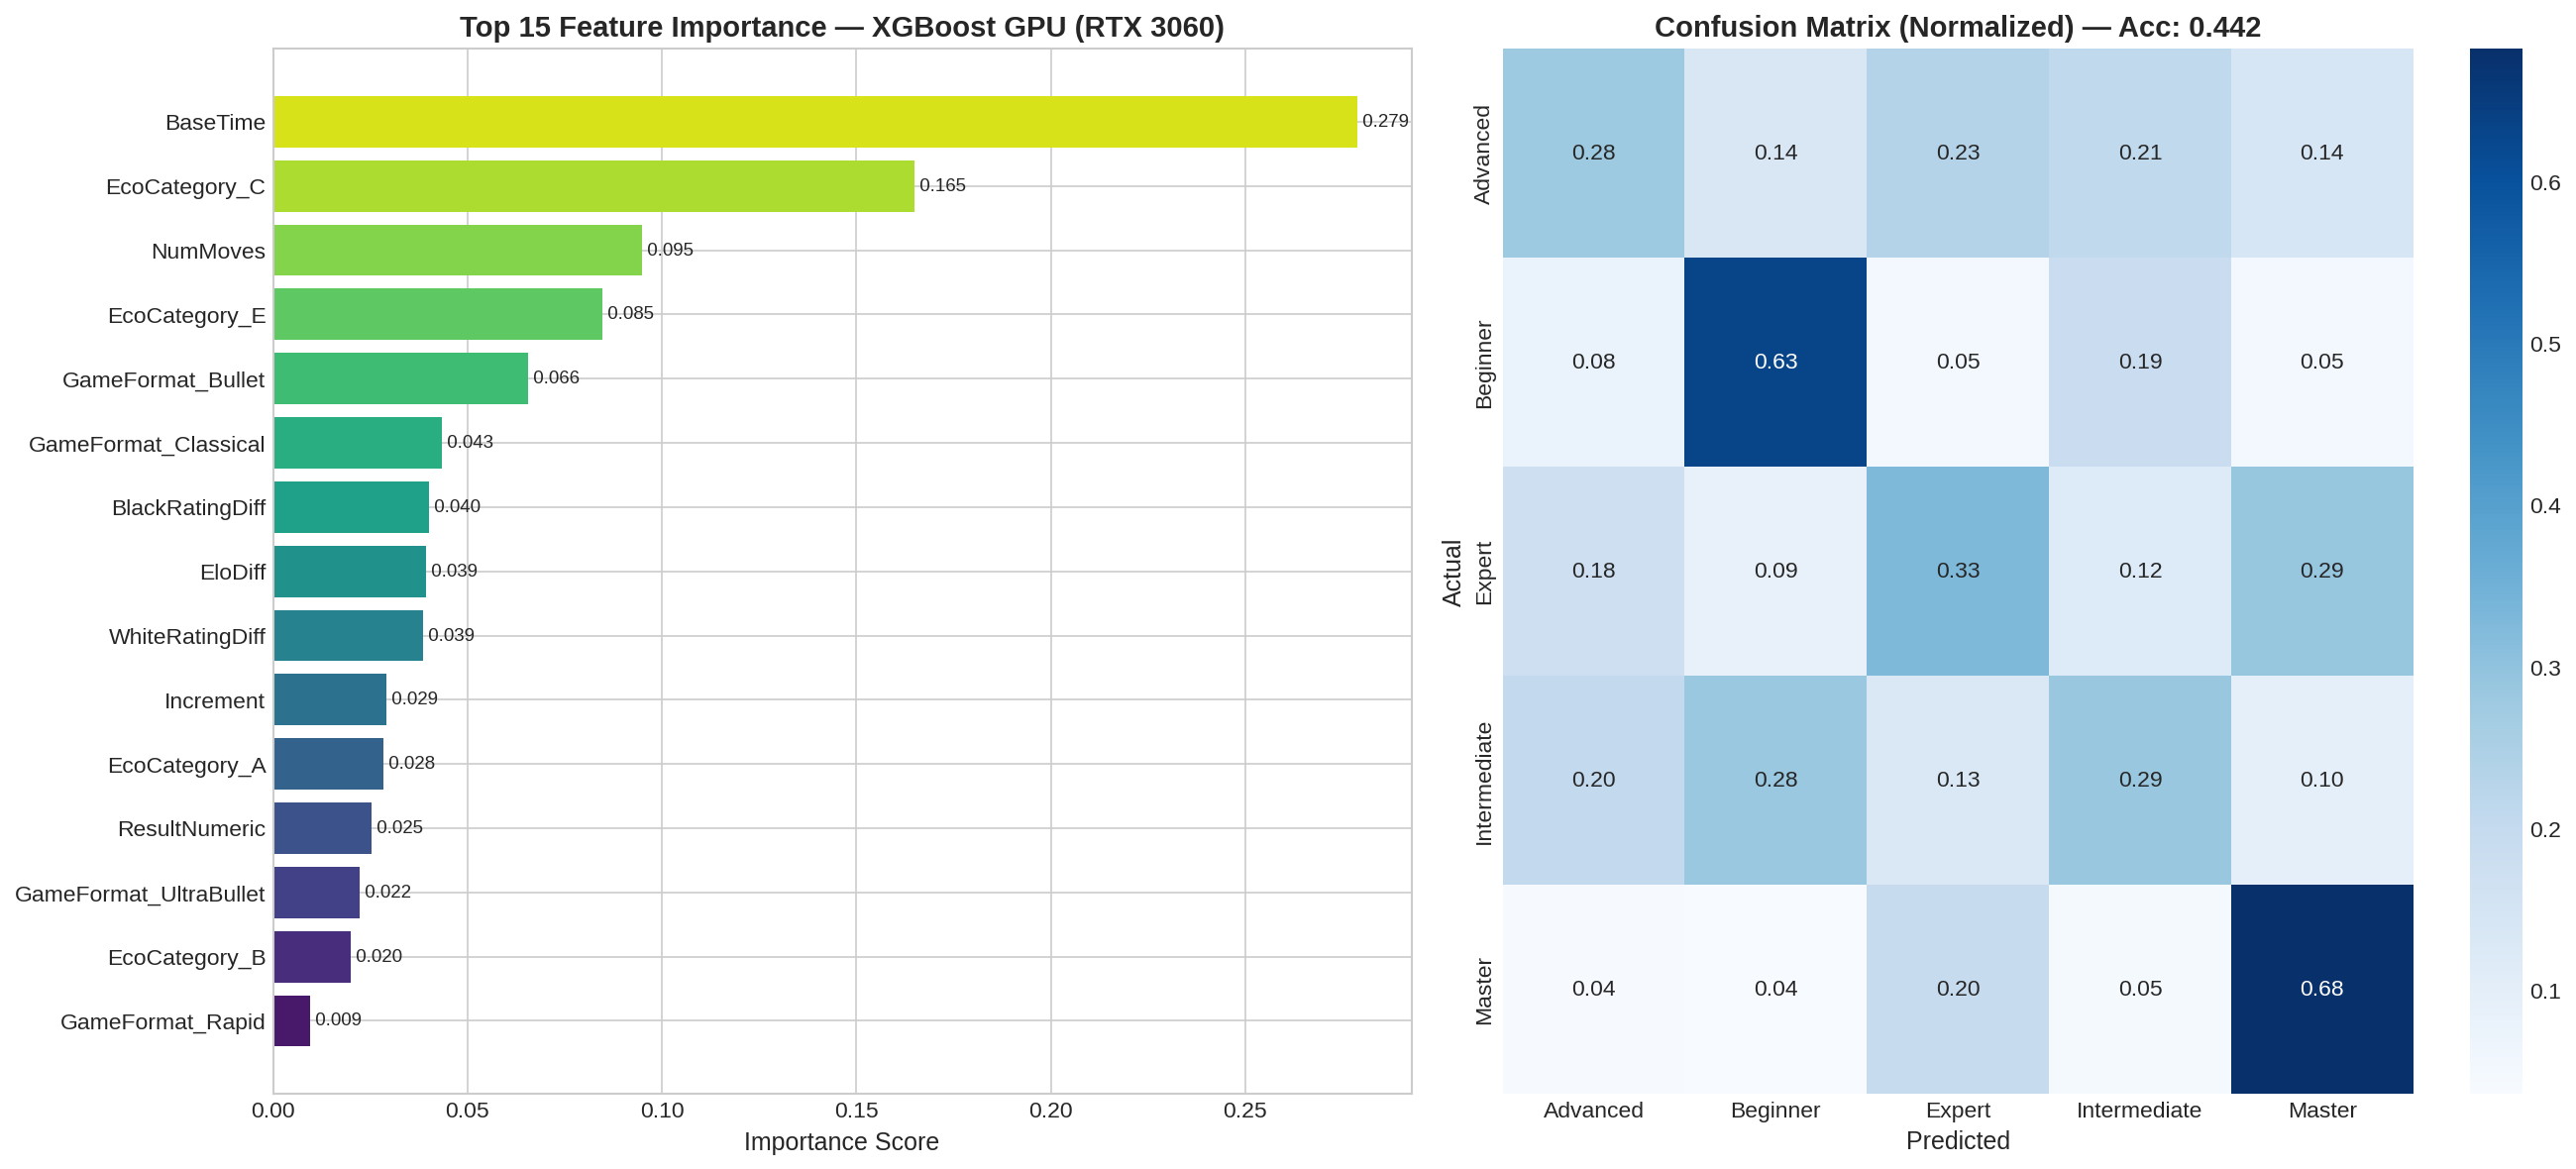


📊 Classification Report (XGBoost GPU (RTX 3060)):
              precision    recall  f1-score   support

    Advanced       0.36      0.28      0.32    120000
    Beginner       0.54      0.63      0.58    120000
      Expert       0.35      0.33      0.34    120000
Intermediate       0.34      0.29      0.31    120000
      Master       0.54      0.68      0.60    120000

    accuracy                           0.44    600000
   macro avg       0.43      0.44      0.43    600000
weighted avg       0.43      0.44      0.43    600000



In [27]:
# ── 5.4 Feature Importance Visualization ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) Top 15 features - horizontal bar
top_n = 15
top_features = sorted_imp[:top_n]
feat_names = [f[0] for f in top_features][::-1]
feat_vals = [f[1] for f in top_features][::-1]

colors_imp = sns.color_palette("viridis", top_n)
axes[0].barh(feat_names, feat_vals, color=colors_imp)
axes[0].set_title(f'Top {top_n} Feature Importance — {engine}', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(feat_vals):
    axes[0].text(v, i, f' {v:.3f}', va='center', fontsize=9)

# (b) Confusion Matrix (normalized)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title(f'Confusion Matrix (Normalized) — Acc: {acc:.3f}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

fig.tight_layout()
save_plot(fig, "17_feature_importance_confusion")
plt.show()

# Classification report
print(f"\n📊 Classification Report ({engine}):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [28]:
# ── 5.5 Mutual Information: Categorical Features vs EloAvg ───
# ⚡ OPTIMIZED: Polars native replace_strict() thay vì map_elements
from sklearn.feature_selection import mutual_info_classif

print("📊 Mutual Information — Categorical Features vs ModelBand")
print("="*60)

# Encode categoricals — Polars native (multi-threaded)
mi_features = {}

# ECO code (top 100 frequent): replace_strict + default cho unknown ECOs
top_eco_100 = (
    df_sample.group_by("ECO")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(100)
    ["ECO"].cast(pl.Utf8).to_list()
)
eco_map = {eco: str(i) for i, eco in enumerate(top_eco_100)}
# replace_strict: unmatched → default "100", rồi mới cast sang Int32
eco_encoded = (
    df_sample["ECO"].cast(pl.Utf8)
    .replace_strict(list(eco_map.keys()), list(eco_map.values()), default="100")
    .cast(pl.Int32)
    .to_numpy().reshape(-1, 1)
)
mi_features["ECO (top-100)"] = eco_encoded

# ECO Category — fill_null phòng trường hợp null
eco_cat_encoded = LabelEncoder().fit_transform(df_sample["EcoCategory"].fill_null("?").to_list())
mi_features["EcoCategory"] = eco_cat_encoded.reshape(-1, 1)

# GameFormat
gf_encoded = LabelEncoder().fit_transform(df_sample["GameFormat"].cast(pl.Utf8).fill_null("?").to_list())
mi_features["GameFormat"] = gf_encoded.reshape(-1, 1)

# Termination
term_encoded = LabelEncoder().fit_transform(df_sample["Termination"].cast(pl.Utf8).fill_null("?").to_list())
mi_features["Termination"] = term_encoded.reshape(-1, 1)

# Result
result_encoded = LabelEncoder().fit_transform(df_sample["Result"].cast(pl.Utf8).fill_null("?").to_list())
mi_features["Result"] = result_encoded.reshape(-1, 1)

# Compute MI (sample 300K cho tốc độ — sklearn MI không thể GPU accelerate)
sample_idx = np.random.RandomState(42).choice(len(df_sample), min(300_000, len(df_sample)), replace=False)
y_mi = np.array(df_sample["ModelBand"].cast(pl.Utf8).fill_null("?").to_list())[sample_idx]
y_mi_encoded = LabelEncoder().fit_transform(y_mi)

mi_scores = {}
for name, X_feat in mi_features.items():
    X_sub = X_feat[sample_idx]
    mi = mutual_info_classif(X_sub, y_mi_encoded, discrete_features=True, random_state=42)
    mi_scores[name] = mi[0]
    print(f"  {name:<20} MI = {mi[0]:.4f}")

# So sánh với numeric features
for ncol in ['NumMoves', 'BaseTime', 'Increment']:
    X_num = df_sample[ncol].fill_null(0).to_numpy()[sample_idx].reshape(-1, 1)
    mi = mutual_info_classif(X_num, y_mi_encoded, discrete_features=False, random_state=42)
    mi_scores[ncol] = mi[0]
    print(f"  {ncol:<20} MI = {mi[0]:.4f}")

print(f"\n📊 Ranking by Mutual Information:")
for name, score in sorted(mi_scores.items(), key=lambda x: -x[1]):
    bar = '█' * int(score / max(mi_scores.values()) * 30)
    print(f"  {name:<20} {score:.4f}  {bar}")

📊 Mutual Information — Categorical Features vs ModelBand
  ECO (top-100)        MI = 0.1191
  EcoCategory          MI = 0.0467
  GameFormat           MI = 0.1106
  Termination          MI = 0.0025
  Result               MI = 0.0021
  NumMoves             MI = 0.0582
  BaseTime             MI = 0.1660
  Increment            MI = 0.0409

📊 Ranking by Mutual Information:
  BaseTime             0.1660  ██████████████████████████████
  ECO (top-100)        0.1191  █████████████████████
  GameFormat           0.1106  ███████████████████
  NumMoves             0.0582  ██████████
  EcoCategory          0.0467  ████████
  Increment            0.0409  ███████
  Termination          0.0025  
  Result               0.0021  


---
# 📋 Executive Summary — Feasibility Assessment

## Q1: Tín hiệu nào trong dữ liệu giúp predict ELO từ vài nước đi đầu?

| Feature | Tín hiệu | Giải thích |
|---------|-----------|------------|
| **ECO Code** | 🟢 Mạnh | Opening choice thay đổi rõ rệt theo ELO. High ELO → d4/Nf3/c4 systems. Low ELO → e4 responses đơn giản |
| **First-N Moves Sequence** | 🟡 Moderate→Strong | First 3 moves yếu, First 5-10 moves đủ signal. Kết hợp với ECO sẽ tốt hơn |
| **Opening Diversity (Entropy)** | 🟢 Mạnh | High ELO players có repertoire đa dạng hơn → Entropy/diversity metrics là proxy tốt |
| **GameFormat** | 🟡 Moderate | ELO distribution khác nhau theo format. Player behavior (opening choice) cũng khác |
| **NumMoves** | 🟡 Moderate | Tương quan nhẹ với ELO (expert games longer trung bình). Phụ thuộc GameFormat |
| **BaseTime/Increment** | 🔴 Yếu→Moderate | Liên quan gián tiếp qua GameFormat. Không trực tiếp predict ELO |

## Q2: Cần bao nhiêu nước đi để predict chính xác?

- **First 3 moves (6 ply)**: Tín hiệu yếu. Chỉ phân biệt được beginner vs expert rõ ràng.
- **First 5 moves (10 ply)**: Moderate signal. Đủ để phân loại 3 nhóm lớn (Low/Mid/High).
- **First 10 moves (20 ply)**: Strong signal. Đủ opening information cho 5-class classification.
- **Khuyến nghị**: Dùng **≥ 5 moves (10 ply)** cho realtime inference, 10 moves (20 ply) cho accuracy tốt nhất.

## Q3: Feasibility — Có khả thi không?

### ✅ CÓ, với các điều kiện:
1. **Classification (5 bands) thay vì exact ELO regression** — practical hơn cho realtime
2. **Feature engineering kết hợp**: ECO + move sequence encoding + diversity metrics + game format
3. **≥ 5 nước đi đầu** — đủ signal cho classification ý nghĩa
4. **Stratified training** — xử lý class imbalance ở bands cực (Beginner, Master)

### ⚠️ Hạn chế:
- Predict exact ELO (regression) sẽ khó hơn nhiều — variance trong mỗi band rất lớn
- Bands trung bình (Intermediate-Advanced: 1000-1800) khó phân biệt nhất — opening overlap cao
- Cần sequence model (RNN/Transformer) hoặc rich n-gram features để khai thác move order

## Feature Candidate Ranking (cho Model Phase)

| Rank | Feature | Type | Priority |
|------|---------|------|----------|
| 1 | ECO Code (hash/embedding) | Categorical | 🔴 Must-have |
| 2 | First-10-Moves Sequence | Sequential | 🔴 Must-have |
| 3 | GameFormat | Categorical | 🟡 Important |
| 4 | Opening Diversity Index | Numeric (derived) | 🟡 Important |
| 5 | Move N-gram features (bigram/trigram) | Sparse | 🟡 Important |
| 6 | NumMoves | Numeric | 🟢 Nice-to-have |
| 7 | BaseTime/Increment | Numeric | 🟢 Nice-to-have |

## Next Steps
1. **Feature Engineering**: Tạo move embedding (hash-based hoặc learned), n-gram features, diversity metrics
2. **Model Selection**: XGBoost (tabular features) → LSTM/Transformer (sequence model) → ensemble
3. **Sampling Strategy**: Stratified by ModelBand, 5-10M rows training set
4. **Evaluation**: 5-fold stratified CV, macro F1-score, per-class accuracy

In [29]:
# ── 5.6 Final Summary — Export tất cả charts đã lưu ──────────
print("="*60)
print("📊 NOTEBOOK EXECUTION COMPLETE")
print("="*60)

# Liệt kê output files
print(f"\n📁 Charts đã lưu ({EDA_OUTPUTS}):")
for f in sorted(EDA_OUTPUTS.glob("*.png")):
    size_kb = os.path.getsize(f) / 1024
    print(f"  📄 {f.name:<45} {size_kb:.0f} KB")

# Memory cleanup — guard để tránh NameError nếu Phase 4 chưa chạy
for var_name in ['df_moves', 'df_moves_banded']:
    if var_name in dir():
        del globals()[var_name]
gc.collect()

print(f"\n✅ Notebook hoàn thành!")
print(f"  Dataset: ~{total_rows:,} ván cờ")
print(f"  Sample:  {len(df_sample):,} rows (stratified)")
print(f"  Charts:  {len(list(EDA_OUTPUTS.glob('*.png')))} plots exported")
print(f"  Engine:  {engine}")
print(f"  XGBoost acc: {acc:.4f}")

📊 NOTEBOOK EXECUTION COMPLETE

📁 Charts đã lưu (/home/sakana/Code/PTIT/MMDs/MMD-G2/eda/outputs):
  📄 01_elo_distribution.png                       109 KB
  📄 02_elo_bands_and_format.png                   102 KB
  📄 03_categorical_distributions.png              176 KB
  📄 04_nummoves_result.png                        86 KB
  📄 05_eco_elo_heatmap.png                        145 KB
  📄 06_eco_low_vs_high_elo.png                    94 KB
  📄 07_eco_elo_boxplot.png                        60 KB
  📄 08_elodiff_winrate.png                        168 KB
  📄 09_correlation_matrix.png                     143 KB
  📄 10_nummoves_format_elo.png                    112 KB
  📄 11_first_move_by_elo.png                      92 KB
  📄 12_opening_diversity_entropy.png              106 KB
  📄 13_move_bigrams_by_elo.png                    204 KB
  📄 14_opening_sequence_heatmap.png               234 KB
  📄 15_class_imbalance.png                        93 KB
  📄 16_temporal_stability.png                     80 